# Separator gas release → OpenFOAM dispersion
### An executed industrial study workflow with NeqSim process coupling

**Question:** What gas cloud develops when a 25 mm opening occurs in a high-pressure gas line
downstream of a three-phase separation and gas-conditioning train, and how do isolation,
wind and discretization affect the result?

This notebook runs a **real NeqSim flowsheet and real three-dimensional OpenFOAM CFD**.
All fluid, equipment, inventory and layout inputs are **synthetic, representative industrial
assumptions**. No operating asset or confidential plant data are represented.

The deliverable follows a safety-study structure: study basis, process balances, scenario selection,
release history, CFD handoff, mesh/boundaries, calculated cloud fields, virtual detectors, conservation,
sensitivity, limitations and a reproducible case archive. **Engineering status: unqualified
demonstration; these distances are not design exclusion zones or approved detector locations.**

Based on [Automatic Release and Gas Dispersion Scenarios](https://equinor.github.io/neqsim/process/safety/release-dispersion-scenarios.html).
The native export is a starting point; this notebook supplies the missing CFD case construction.

## 1 · Study basis and execution

| Item | Basis |
|---|---|
| Feed | 70 kg/s, 72 bara, 65°C; methane-rich gas, condensate and water |
| Process | Inlet valve; HP separation at 65 bara; gas cooling to 30°C; scrubber; trim heating to 50°C; oil separation at 8 and 2 bara |
| Release location | Conditioned HP gas line, downstream of E-102, inside one gas-only isolation envelope |
| Opening | 25 mm equivalent circular hole; discharge coefficient 0.62; horizontal +x |
| Trapped gas | 24 m³: 16 m³ gas section plus DN300 piping, 113.18 m long; assumed, not drawing-verified |
| Isolation | Supply maintained for 5 s after leak initiation; then zero replenishment, adiabatic trapped-gas depletion |
| Atmosphere | 1.01325 bara, 10°C; uniform neutral wind in +x; 3 and 6 m/s |
| CFD clock | 0–5 s ventilation startup; 0.05 s numerical source ramp; source isolation at 10.05 s; end at 25 s |
| Domain | x = −6…24 m (extended check to 60 m), y = −6…6 m, z = 0…9 m; deck, vessels, cooler skid and rack |
| Solver | OpenCFD OpenFOAM v1912, rhoReactingBuoyantFoam, nonreacting RANS k–epsilon |
| Physics | Compressible continuity/momentum, gravity, sensible enthalpy and gas/air species transport |
| Mesh | Cartesian solid-cell removal; 0.5 m base spacing and 1 m comparison; no near-wall or nozzle resolution |
| Outputs | 3D gas cloud, plan/elevation concentration, velocity, detectors, cloud volumes, source and conservation audits |

**Runtime:** CPU-only Linux/Colab. Building NeqSim and running five CFD cases can take tens of
minutes, depending on the runtime. The stored outputs can be read without rerunning.
Set `NEQSIM_SOURCE_REF` to the retained commit to reproduce this run, or leave `master` to evaluate
current source. OpenFOAM Foundation releases have different dictionaries and are not silently substituted.

### Run this entire study in Google Colab

1. Open the notebook and select **Runtime → Change runtime type → Python 3 / CPU**.
2. Select **Runtime → Run all**. The next three cells install Python packages, compile
   NeqSim from `master`, and install/check OpenCFD OpenFOAM v1912. No local NeqSim
   installation, GPU, Drive mount, CFD license or external case download is required.
3. Keep the runtime connected. The notebook calculates the process and release, creates
   all meshes and dictionaries, runs `checkMesh` and the CFD solver for **all five cases**,
   and reads the solved fields to produce every stored figure and numerical table.
4. Review the native release diagnostics, mesh checks, source conservation, species budget,
   Courant numbers and domain-truncation flags before interpreting the gas-cloud distances.
5. Use the archive download button at the end to save the generated cases and figures.

The default is a fresh solver run; `OPENFOAM_VALIDATED_RUN` is only an optional validation
cache for the authoring environment. Leave it unset in Colab. To reproduce the retained
NeqSim version, set `os.environ["NEQSIM_SOURCE_REF"] = VALIDATED_COMMIT` in the source-build
cell **before** the fetch. Restart the session before changing a JAR already loaded by JPype.

If setup fails, read `neqsim-master-source/safety-notebook-build.log`. A solver failure prints
the end of the relevant case log and stops the notebook. The installation deliberately checks
the OpenFOAM distribution/version: a different package requires an assessed case conversion.


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

requirements = {
    "jpype": "JPype1==1.7.1",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "jsonschema": "jsonschema",
    "pyvista": "pyvista==0.49.0",
}
missing = [p for m, p in requirements.items() if importlib.util.find_spec(m) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
# Recent VTK supports headless EGL rendering without an X server.
import importlib.metadata as metadata

if int(metadata.version("vtk").split(".")[1]) < 4:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "vtk>=9.4"], check=True)
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ["VTK_DEFAULT_OPENGL_WINDOW"] = "vtkEGLRenderWindow"
print("Python", sys.version.split()[0])

Python 3.12.14


In [2]:
import hashlib
import json
import shutil
import zipfile
from pathlib import Path

import jpype

NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
VALIDATED_COMMIT = "3e35bb26591a0d838abed7fdb2d75a35ff2b136c"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-master-source")).resolve()
prebuilt_jar = os.environ.get("NEQSIM_SOURCE_JAR")


def command(arguments, cwd=None):
    return subprocess.check_output(arguments, cwd=cwd, text=True).strip()


if prebuilt_jar:
    source_jar = Path(prebuilt_jar).resolve()
    audit_path = os.environ.get("NEQSIM_AUDITED_SOURCE_MANIFEST")
    if audit_path:
        audit = json.loads(Path(audit_path).read_text())
        for relative, expected in audit["files"].items():
            file_path = source_root / relative
            data = file_path.read_bytes()
            header = f"blob {len(data)}\0".encode()
            assert hashlib.sha1(header + data).hexdigest() == expected, relative
        source_commit = audit["sha"]
        source_basis = "Full connector-tree blob verification"
    else:
        source_commit = command(["git", "rev-parse", "HEAD"], source_root)
        assert not command(["git", "status", "--porcelain", "--untracked-files=no"], source_root)
        source_basis = "Clean Git checkout"
else:
    if not source_root.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/equinor/neqsim.git", str(source_root)],
            check=True,
        )
    subprocess.run(["git", "fetch", "origin", NEQSIM_SOURCE_REF], cwd=source_root, check=True)
    subprocess.run(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=source_root, check=True)
    source_commit = command(["git", "rev-parse", "HEAD"], source_root)
    if shutil.which("javac") is None:
        subprocess.run(["apt-get", "-qq", "update"], check=True)
        subprocess.run(["apt-get", "-qq", "install", "-y", "openjdk-17-jdk-headless"], check=True)
    subprocess.run(["chmod", "+x", str(source_root / "mvnw")], check=True)
    build_log = source_root / "safety-notebook-build.log"
    with build_log.open("w") as log:
        built = subprocess.run(
            [
                "./mvnw",
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "compile",
                "dependency:build-classpath",
                "-Dmdep.outputFile=target/runtime-classpath.txt",
            ],
            cwd=source_root,
            stdout=log,
            stderr=subprocess.STDOUT,
        )
    if built.returncode:
        print(build_log.read_text()[-12000:])
        raise RuntimeError("NeqSim source build failed; see retained build log")
    source_jar = source_root / "target/neqsim-safety-master.jar"
    with zipfile.ZipFile(source_jar, "w", zipfile.ZIP_DEFLATED) as archive:
        for file_path in sorted((source_root / "target/classes").rglob("*")):
            if file_path.is_file():
                archive.write(file_path, file_path.relative_to(source_root / "target/classes"))
    source_basis = "Fresh master/ref build"

classpath = (source_root / "target/runtime-classpath.txt").read_text().strip().split(os.pathsep)
assert source_jar.is_file()
assert len(source_commit) == 40
if jpype.isJVMStarted():
    raise RuntimeError("Restart the runtime so the intended NeqSim JAR is loaded first")
jpype.addClassPath(str(source_jar))
for dependency in classpath:
    jpype.addClassPath(dependency)
jpype.startJVM(convertStrings=True)
J = jpype.JClass
Inventory = J("neqsim.process.safety.release.ReleaseInventory")
loaded_from = str(Inventory.class_.getProtectionDomain().getCodeSource().getLocation())
from urllib.parse import unquote, urlparse

assert Path(unquote(urlparse(loaded_from).path)).resolve() == source_jar
provenance = {
    "source_repository": "https://github.com/equinor/neqsim",
    "requested_ref": NEQSIM_SOURCE_REF,
    "source_commit": source_commit,
    "source_basis": source_basis,
    "jar_sha256": hashlib.sha256(source_jar.read_bytes()).hexdigest(),
    "loaded_class_location": loaded_from,
    "java": str(J("java.lang.System").getProperty("java.version")),
    "python": sys.version.split()[0],
}
print(json.dumps(provenance, indent=2))

{
  "source_repository": "https://github.com/equinor/neqsim",
  "requested_ref": "master",
  "source_commit": "3e35bb26591a0d838abed7fdb2d75a35ff2b136c",
  "source_basis": "Full connector-tree blob verification",
  "jar_sha256": "b14f97109b0ee230e97abaa7df54894cebeee78d250aebf87d8a0d87a1918b48",
  "loaded_class_location": "file:/workspace/scratch/d59c271f86ae/neqsim-source/target/neqsim-current.jar",
  "java": "17.0.20",
  "python": "3.12.14"
}


In [3]:
import shutil

if shutil.which("rhoReactingBuoyantFoam") is None:
    subprocess.run(["apt-get", "-qq", "update"], check=True)
    subprocess.run(["apt-get", "-qq", "install", "-y", "openfoam"], check=True)
os.environ.setdefault("WM_PROJECT_DIR", "/usr/share/openfoam")
os.environ.setdefault("WM_PROJECT_VERSION", "v1912")
os.environ.setdefault("FOAM_ETC", "/usr/share/openfoam/etc")
help_text = subprocess.check_output(
    ["rhoReactingBuoyantFoam", "-help"], text=True, stderr=subprocess.STDOUT
)
assert (
    "1912" in help_text
), "This case is verified for OpenCFD v1912; assess other versions separately"
print("\n".join(line for line in help_text.splitlines() if "Using:" in line or "Build:" in line))
versions = {
    name: metadata.version(name)
    for name in ["JPype1", "numpy", "pandas", "scipy", "matplotlib", "pyvista", "vtk", "jsonschema"]
}
print(versions)
results_dir = Path("separator_release_results")
results_dir.mkdir(exist_ok=True)
figures_dir = results_dir / "figures"
figures_dir.mkdir(exist_ok=True)

if shutil.which("ffmpeg") is None:
    subprocess.run(["apt-get", "-qq", "update"], check=True)
    subprocess.run(["apt-get", "-qq", "install", "-y", "ffmpeg"], check=True)
print(subprocess.check_output(["ffmpeg", "-version"], text=True).splitlines()[0])

Using: OpenFOAM- (1912) - visit www.openfoam.com
Build:  (patch=200626)
{'JPype1': '1.7.1', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'matplotlib': '3.11.2', 'pyvista': '0.49.0', 'vtk': '9.7.0', 'jsonschema': '4.26.0'}
ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers


## 2 · The process is the source of the release state

The model uses **SRK with the classic mixing rule**, named components rather than an uncharacterized
plus fraction, and a multiphase check. The trim heater creates a controlled superheat margin in the
gas-only isolated section. It is an explicit synthetic design choice, with its heat duty reported.
It should be replaced by the actual gas-conditioning arrangement in an asset study.

The HP separator contains liquid, but **its liquid inventory is excluded from the selected gas-line
isolation envelope**. Condensate return and produced-water outlets are counted as separate process
products. The MP/LP flash-gas products are shown as recovery-system interfaces, not unmodelled recycles.

In [4]:
"""Executable NeqSim process and source-term calculations for the notebook."""

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import jpype


def build_process():
    J = jpype.JClass
    fluid = J("neqsim.thermo.system.SystemSrkEos")(338.15, 72.0)
    composition = {
        "nitrogen": 0.01,
        "CO2": 0.02,
        "methane": 0.74,
        "ethane": 0.075,
        "propane": 0.045,
        "n-butane": 0.025,
        "n-pentane": 0.015,
        "n-heptane": 0.03,
        "n-decane": 0.02,
        "water": 0.02,
    }
    assert abs(sum(composition.values()) - 1) < 1e-12
    for name, fraction in composition.items():
        fluid.addComponent(name, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    Stream = J("neqsim.process.equipment.stream.Stream")
    Valve = J("neqsim.process.equipment.valve.ThrottlingValve")
    Separator = J("neqsim.process.equipment.separator.ThreePhaseSeparator")
    Cooler = J("neqsim.process.equipment.heatexchanger.Cooler")
    Heater = J("neqsim.process.equipment.heatexchanger.Heater")
    feed = Stream("Wellstream", fluid)
    feed.setFlowRate(70.0, "kg/sec")
    inlet = Valve("PCV-101", feed)
    inlet.setOutletPressure(65.0)
    hp = Separator("V-101 HP separator", inlet.getOutletStream())
    cooler = Cooler("E-101 gas cooler", hp.getGasOutStream())
    cooler.setOutTemperature(303.15)
    scrubber = Separator("V-102 gas scrubber", cooler.getOutletStream())
    heater = Heater("E-102 gas trim heater", scrubber.getGasOutStream())
    heater.setOutTemperature(323.15)
    # Controlled superheat provides a gas-only isolated section for the example.
    mp_valve = Valve("LCV-101", hp.getOilOutStream())
    mp_valve.setOutletPressure(8.0)
    mp = Separator("V-201 MP separator", mp_valve.getOutletStream())
    lp_valve = Valve("LCV-201", mp.getOilOutStream())
    lp_valve.setOutletPressure(2.0)
    lp = Separator("V-301 LP separator", lp_valve.getOutletStream())
    process = J("neqsim.process.processmodel.ProcessSystem")()
    process.setName("Synthetic offshore separation and gas conditioning")
    units = [feed, inlet, hp, cooler, scrubber, heater, mp_valve, mp, lp_valve, lp]
    for unit in units:
        process.add(unit)
    process.run()
    gas = heater.getOutletStream()
    gas.setName("G-102 conditioned HP gas")
    outputs = {
        "Conditioned HP gas": gas,
        "HP produced water": hp.getWaterOutStream(),
        "Scrubber condensate": scrubber.getOilOutStream(),
        "Scrubber water": scrubber.getWaterOutStream(),
        "MP flash gas": mp.getGasOutStream(),
        "MP water": mp.getWaterOutStream(),
        "LP flash gas": lp.getGasOutStream(),
        "LP water": lp.getWaterOutStream(),
        "Stabilized oil": lp.getOilOutStream(),
    }
    streams = {"Wellstream": feed, **outputs}
    table = pd.DataFrame(
        [
            {
                "Stream": name,
                "Flow [kg/s]": stream.getFlowRate("kg/sec"),
                "P [bara]": stream.getPressure("bara"),
                "T [C]": stream.getTemperature("C"),
            }
            for name, stream in streams.items()
        ]
    )
    mass_residual = sum(s.getFlowRate("kg/sec") for s in outputs.values()) - 70
    component_residuals = {}

    def component_rate(stream, index):
        f = stream.getFluid()
        comp = f.getComponent(index)
        mass_fraction = comp.getz() * comp.getMolarMass() / f.getMolarMass()
        return stream.getFlowRate("kg/sec") * mass_fraction

    for i in range(fluid.getNumberOfComponents()):
        incoming = component_rate(feed, i)
        outgoing = sum(component_rate(s, i) for s in outputs.values())
        component_residuals[str(fluid.getComponent(i).getName())] = outgoing - incoming
    heat = float(cooler.getDuty()) + float(heater.getDuty())
    energy_residual = sum(
        s.getFluid().getEnthalpy("J/kg") * s.getFlowRate("kg/sec") for s in outputs.values()
    )
    energy_residual -= feed.getFluid().getEnthalpy("J/kg") * feed.getFlowRate("kg/sec") + heat
    checks = {
        "mass_residual_kg_s": mass_residual,
        "max_component_residual_kg_s": max(map(abs, component_residuals.values())),
        "energy_residual_W": energy_residual,
        "cooling_duty_MW": float(cooler.getDuty()) / 1e6,
        "heating_duty_MW": float(heater.getDuty()) / 1e6,
    }
    assert abs(mass_residual) < 1e-7
    assert checks["max_component_residual_kg_s"] < 1e-6
    assert abs(energy_residual) < 20
    return process, gas, table, checks, composition


def inventory_basis(gas):
    J = jpype.JClass
    # Gas-only section downstream of trim heater; separator liquid excluded.
    result = (
        J("neqsim.process.safety.inventory.TrappedInventoryCalculator")()
        .setFluid(gas.getFluid())
        .setOperatingConditions(65.0, "bara", 50.0, "C")
        .addEquipmentVolume("Gas header and heater section", 16.0, 0.0, None)
        .addPipeSegment("DN300 isolated gas piping", 0.30, 113.1768484209, 0.0, None)
        .calculate()
    )
    return result


def screening_cases(gas, inventory):
    J = jpype.JClass
    envelope = J("neqsim.process.processmodel.ProcessSystem")()
    envelope.setName("Gas-only isolation envelope G-102")
    envelope.add(gas)
    weather = (
        J("neqsim.process.safety.BoundaryConditions")
        .builder()
        .ambientTemperature(10.0, "C")
        .windSpeed(3.0)
        .pasquillStabilityClass(jpype.JChar("D"))
        .build()
    )
    generator = (
        J("neqsim.process.safety.scenario.ReleaseDispersionScenarioGenerator")(envelope)
        .boundaryConditions(weather)
        .holeDiameter(25.0, "mm")
        .trappedInventory(inventory)
        .releaseHeight(3.5)
        .releaseDuration(20.0, 1.0)
    )
    cases = generator.generateCfdSourceTermCases()
    case = cases.get(0)
    assert case.validate().isValid()
    return json.loads(str(case.toJson())), case


def source_record_from_frame(frame_json, released_mass_kg):
    """Consume NeqSim's native exchange contract; never supply a substitute rate."""
    frame_type = jpype.JClass("neqsim.process.safety.release.SourceTermFrame")
    frame_type.verifyEnvelope(frame_json)
    frame = json.loads(frame_json)
    source_schema_validator.validate(frame)
    if frame["status"] not in ["VALID", "VALID_WITH_WARNINGS"]:
        raise ValueError(f"Unusable NeqSim source frame: {frame['status']}")
    if frame["schemaVersion"] != "neqsim_safety_source_term.v1":
        raise ValueError("Unsupported NeqSim source-term schema")

    def quantity(parent, key, expected_unit):
        item = parent[key]
        if item["unit"] != expected_unit:
            raise ValueError(f"Unexpected unit for {key}: {item['unit']}")
        return float(item["value"])

    source = frame["source"]
    throat = source["stations"]["THROAT_CRITICAL"]
    upstream = source["stations"]["UPSTREAM_STAGNATION"]
    rate = quantity(source, "massFlowRate", "kg/s")
    # Native advective momentum excludes pressure thrust; add that term explicitly.
    thrust = quantity(source, "advectiveMomentumRate", "N")
    thrust += (
        quantity(throat, "pressure", "Pa") - quantity(source, "backPressure", "Pa")
    ) * quantity(source, "effectiveArea", "m2")
    cp = float(frame["provenance"]["cfdFuelCp_J_kgK"])
    reference_h = float(frame["provenance"]["cfdReferenceEnthalpy_J_kg"])
    equivalent_temperature = (
        283.15 + (quantity(upstream, "specificEnthalpy", "J/kg") - reference_h) / cp
    )
    return {
        "time_s": quantity(frame, "simulationTime", "s"),
        "rate_kg_s": rate,
        "thrust_N": thrust,
        "temperature_K": equivalent_temperature,
        "upstream_temperature_K": quantity(upstream, "temperature", "K"),
        "pressure_bara": quantity(upstream, "pressure", "Pa") / 1e5,
        "throat_temperature_K": quantity(throat, "temperature", "K"),
        "released_from_inventory_kg": released_mass_kg,
    }


def source_history(gas, duration=30, isolation=5, substep=0.5):
    J = jpype.JClass
    prefix = "neqsim.process.safety.release."
    Request = J(prefix + "ReleaseFlowRequest")
    model = J(prefix + "IdealGasReleaseModel")()
    state_type = J(prefix + "ReleaseFlowResult$Station")
    UUID = J("java.util.UUID")
    fluid = gas.getFluid().clone()
    volume = 24.0
    diameter = 0.025
    cd = 0.62
    pressure = 101325.0
    area = math.pi * diameter**2 / 4
    inventory = J(prefix + "ReleaseInventory")(
        "Isolated gas export section", fluid, volume, diameter, cd, pressure, model, substep
    )
    reference = fluid.clone()
    reference.setTemperature(283.15)
    reference.setPressure(1.01325)
    J("neqsim.thermodynamicoperations.ThermodynamicOperations")(reference).TPflash()
    reference.init(3)
    cp = float(reference.getCp("J/kgK"))
    h_reference = float(reference.getEnthalpy("J/kg"))
    mw = float(fluid.getMolarMass())
    records = []
    native_frames = []
    frame_type = J(prefix + "SourceTermFrame")
    metadata = J("java.util.LinkedHashMap")()
    for key, value in {
        "process": "HP/MP/LP separation and conditioned gas export",
        "stream": str(gas.getName()),
        "neqsimCommit": source_commit,
        "inventoryBasis": "24 m3 gas-only isolated envelope; synthetic",
        "isolationDelay_s": str(isolation),
        "inventorySubstep_s": str(substep),
        "cfdFuelCp_J_kgK": str(cp),
        "cfdReferenceEnthalpy_J_kg": str(h_reference),
        "cfdReferenceTemperature_K": "283.15",
        "qualification": "UNQUALIFIED_DEMONSTRATION",
    }.items():
        metadata.put(key, value)
    for second in range(duration + 1):
        current = fluid if second <= isolation else inventory.getThermoSystem()
        request = Request(current, diameter, cd, pressure)
        release = model.calculate(request)
        assert str(release.getStatus()) in ["VALID", "VALID_WITH_WARNINGS"]
        frame = frame_type.calculated(
            "HP-gas-25mm-ESD5s",
            "G-102-opening",
            UUID.randomUUID(),
            second,
            float(second),
            J("java.time.Instant").now(),
            request,
            release,
            metadata,
        ).withLocation(
            "Synthetic deck: metres, +x downwind, +y crosswind, +z upward; deck z=0",
            jpype.JArray(jpype.JDouble)([1.0, 0.5, 3.5]),
            jpype.JArray(jpype.JDouble)([1.0, 0.0, 0.0]),
        )
        frame_json = str(frame.toJson())
        native_frames.append(frame_json)
        records.append(
            source_record_from_frame(frame_json, float(inventory.getBalance().getReleasedMassKg()))
        )
        if second >= isolation and second < duration:
            inventory.runTransient(1.0, UUID.randomUUID())
    balance = inventory.getBalance()
    initial = dict(balance.getInitialComponentMassKg())
    remaining = dict(balance.getRemainingComponentMassKg())
    released = dict(balance.getReleasedComponentMassKg())
    mass_error = max(abs(initial[k] - remaining[k] - released[k]) for k in initial)
    energy_error = (
        balance.getInitialEnergyJ() - balance.getInternalEnergyJ() - balance.getReleasedEnergyJ()
    )
    checks = {
        "inventory_initial_kg": float(sum(initial.values())),
        "inventory_released_kg": float(balance.getReleasedMassKg()),
        "component_closure_kg": float(mass_error),
        "energy_closure_J": float(energy_error),
        "volume_m3": volume,
    }
    assert mass_error < 1e-7
    assert abs(energy_error) < max(1, abs(balance.getInitialEnergyJ()) * 1e-7)
    return records, mw, cp, checks, native_frames


def source_model_audit(gas):
    J = jpype.JClass
    prefix = "neqsim.process.safety.release."
    request = J(prefix + "ReleaseFlowRequest")(gas.getFluid(), 0.025, 0.62, 101325.0)
    hem = J(prefix + "HomogeneousEquilibriumReleaseModel")().calculate(request)
    result = {
        "full_equilibrium_status": str(hem.getStatus()),
        "full_equilibrium_diagnostics": [
            {"code": str(d.getCode()), "message": str(d.getMessage())} for d in hem.getDiagnostics()
        ],
    }
    # Separate comparison at 10 bara, explicitly not the atmospheric source.
    bounded_request = J(prefix + "ReleaseFlowRequest")(gas.getFluid(), 0.025, 0.62, 1e6)
    bounded = J(prefix + "HomogeneousEquilibriumReleaseModel")().calculate(bounded_request)
    result["10_bara_comparison_status"] = str(bounded.getStatus())
    if str(bounded.getStatus()) in ["VALID", "VALID_WITH_WARNINGS"]:
        result["10_bara_comparison_rate_kg_s"] = bounded.getMassFlowRateKgS()
        result["10_bara_comparison_stations"] = [
            {
                "station": str(k),
                "P_bara": s.getPressurePa() / 1e5,
                "T_K": s.getTemperatureK(),
                "gas_mass_fraction": s.getGasMassFraction(),
            }
            for k, s in bounded.getStations().entrySet()
        ]
    return result


def lfl_basis(gas):
    # Representative room-temperature lower/upper limits in air [mole fraction].
    limits = {
        "methane": (0.05, 0.15),
        "ethane": (0.03, 0.125),
        "propane": (0.021, 0.095),
        "n-butane": (0.016, 0.084),
        "n-pentane": (0.015, 0.078),
        "n-heptane": (0.0105, 0.067),
        "nC10": (0.008, 0.054),
    }
    fluid = gas.getFluid()
    composition = {
        str(fluid.getComponent(i).getName()): float(fluid.getComponent(i).getz())
        for i in range(fluid.getNumberOfComponents())
    }
    lower = 1 / sum(composition.get(c, 0) / limits[c][0] for c in limits)
    upper = 1 / sum(composition.get(c, 0) / limits[c][1] for c in limits)
    return composition, lower, upper

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def style():
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "font.size": 10,
            "axes.titlesize": 13,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.18,
            "axes.prop_cycle": plt.cycler(color=["#176baf", "#eb6b45", "#14a399", "#8a5db7"]),
        }
    )


def process_diagram(table, destination):
    fig, ax = plt.subplots(figsize=(14, 6.5))
    fig.patch.set_facecolor("#091c31")
    ax.set_facecolor("#091c31")
    ax.set(xlim=(0, 15), ylim=(0, 7))
    ax.axis("off")
    positions = {
        "Wellstream": (1, 4.8),
        "V-101\nHP separator": (4, 4.8),
        "E-101\nGas cooler": (7, 4.8),
        "V-102\nScrubber": (10, 4.8),
        "E-102\nTrim heater": (13, 4.8),
        "V-201\nMP separator": (6, 2.1),
        "V-301\nLP separator": (10, 2.1),
    }
    for label, (x, y) in positions.items():
        ax.add_patch(
            FancyBboxPatch(
                (x - 0.8, y - 0.52),
                1.6,
                1.04,
                boxstyle="round,pad=0.10",
                facecolor="#174563",
                edgecolor="#6bb9e0",
                linewidth=1.5,
            )
        )
        ax.text(x, y, label, color="white", ha="center", va="center", fontsize=11)

    def arrow(a, b, color, label=None):
        ax.add_patch(
            FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=16, color=color, linewidth=2)
        )
        if label:
            ax.text(
                (a[0] + b[0]) / 2,
                (a[1] + b[1]) / 2 + 0.2,
                label,
                color=color,
                ha="center",
                fontsize=9,
            )

    for a, b in [(1, 4), (4, 7), (7, 10), (10, 13)]:
        arrow((a + 0.9, 4.8), (b - 0.9, 4.8), "#5bd4ee")
    arrow((4, 4.15), (4, 2.1), "#ffbf59")
    arrow((4, 2.1), (5.1, 2.1), "#ffbf59", "8 bara")
    arrow((6.9, 2.1), (9.1, 2.1), "#ffbf59", "2 bara")
    arrow((10.9, 2.1), (14, 2.1), "#ffbf59", "Stabilized oil")
    arrow((13.9, 4.8), (14.7, 4.8), "#ff6474")
    ax.text(
        13,
        6.1,
        "SELECTED RELEASE\n25 mm · 65 bara · 50°C",
        color="#ff8d98",
        ha="center",
        fontsize=11,
        weight="bold",
    )
    ax.plot([13, 13], [5.4, 5.85], color="#ff6474")
    ax.text(1, 5.65, "70 kg/s\n72 bara · 65°C", color="#b8d6e8", ha="center", fontsize=10)
    ax.text(4, 5.65, "65 bara", color="#b8d6e8", ha="center")
    ax.text(7, 5.65, "30°C", color="#b8d6e8", ha="center")
    for x in [6, 10]:
        arrow((x, 2.73), (x, 3.5), "#5bd4ee")
        ax.text(x, 3.6, "Flash gas to recovery", color="#5bd4ee", ha="center", fontsize=9)
    ax.text(
        0.3,
        0.65,
        "Blue: gas    Amber: oil/condensate    Water outlets included in balance table",
        color="#bed4e2",
        fontsize=11,
    )
    ax.text(
        0.3,
        0.15,
        "Synthetic industrial process · full NeqSim flowsheet · diagram is not a P&ID",
        color="#7f9db4",
        fontsize=10,
    )
    ax.set_title(
        "Separation → gas conditioning → isolated gas-line release",
        color="white",
        fontsize=18,
        pad=18,
    )
    fig.savefig(destination, dpi=150, facecolor=fig.get_facecolor(), bbox_inches="tight")
    return fig


def source_figure(history, destination):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
    plots = [
        ("rate_kg_s", "Gas discharge [kg/s]", "#176baf"),
        ("pressure_bara", "Isolated pressure [bara]", "#14a399"),
        ("upstream_temperature_K", "Inventory temperature [K]", "#8a5db7"),
        ("released_from_inventory_kg", "Mass removed after isolation [kg]", "#eb6b45"),
    ]
    for ax, (column, label, color) in zip(axes.flat, plots):
        ax.plot(history.time_s, history[column], color=color, linewidth=2.5)
        ax.axvline(5, color="#d25855", linestyle="--", label="Supply isolated at 5 s")
        ax.set(xlabel="Time after leak onset [s]", ylabel=label)
        ax.legend(fontsize=8)
    fig.suptitle("Isolation stops replenishment; trapped gas continues to escape", fontsize=16)
    fig.savefig(destination, dpi=160, bbox_inches="tight")
    return fig


def detector_figure(table, destination):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    time = table.time_s - 5
    for i in range(1, 5):
        axes[0].plot(time, table[f"D{i}_percent_LFL"], label=f"D{i}", linewidth=2)
    for value in [20, 60, 100]:
        axes[0].axhline(value, color="gray", linestyle="--", alpha=0.55)
        axes[0].text(0, value + 3, f"{value}% LFL", fontsize=8)
    axes[0].set(
        xlabel="Time after leak onset [s]",
        ylabel="Concentration [% LFL]",
        title="Virtual point detectors (no response delay)",
        xlim=(-1, 20),
    )
    axes[0].legend(ncol=4, loc="upper left")
    axes[1].plot(time, table.flammable_volume_m3, label="Between LFL and UFL", linewidth=2.5)
    axes[1].plot(time, table.half_lfl_volume_m3, label="At least 50% LFL", linewidth=2.5)
    axes[1].set(
        xlabel="Time after leak onset [s]",
        ylabel="Cloud volume [m³]",
        title="Resolved-cell cloud volumes",
        xlim=(-1, 20),
    )
    axes[1].legend()
    fig.savefig(destination, dpi=160, bbox_inches="tight")
    return fig


def budget_figure(table, destination):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].plot(table.time_s, table.cloud_fuel_kg, label="CFD inventory", linewidth=2.3)
    axes[0].plot(
        table.time_s,
        table.net_mass_integral_kg,
        "--",
        label="Integrated net boundary flux",
        linewidth=2.3,
    )
    axes[0].set(
        xlabel="CFD clock [s]",
        ylabel="Released-gas mass [kg]",
        title="Species inventory and flux audit",
    )
    axes[0].legend()
    axes[1].plot(table.time_s, table.reconstructed_balance_kg, color="#eb6b45", linewidth=2)
    axes[1].set(
        xlabel="CFD clock [s]",
        ylabel="Residual [kg]",
        title="Includes 0.5 s output quadrature error",
    )
    fig.savefig(destination, dpi=160, bbox_inches="tight")
    return fig

,Stream,Flow [kg/s],P [bara],T [C]
0,Wellstream,70.00000,72.0,65.00000
1,Conditioned HP gas,47.76978,65.0,50.00000
2,HP produced water,0.77538,65.0,63.16043
3,Scrubber condensate,2.21837,65.0,30.00000
4,Scrubber water,0.13544,65.0,30.00000
5,MP flash gas,2.31274,8.0,51.64798
6,MP water,0.00000,8.0,51.64798
7,LP flash gas,0.64735,2.0,46.15856
8,LP water,0.00000,2.0,46.15856
9,Stabilized oil,16.14095,2.0,46.15856


,Check / duty,Value
0,mass_residual_kg_s,-2.535216e-11
1,max_component_residual_kg_s,9.663381e-12
2,energy_residual_W,-4.059276e-03
3,cooling_duty_MW,-5.079755e+00
4,heating_duty_MW,2.476702e+00


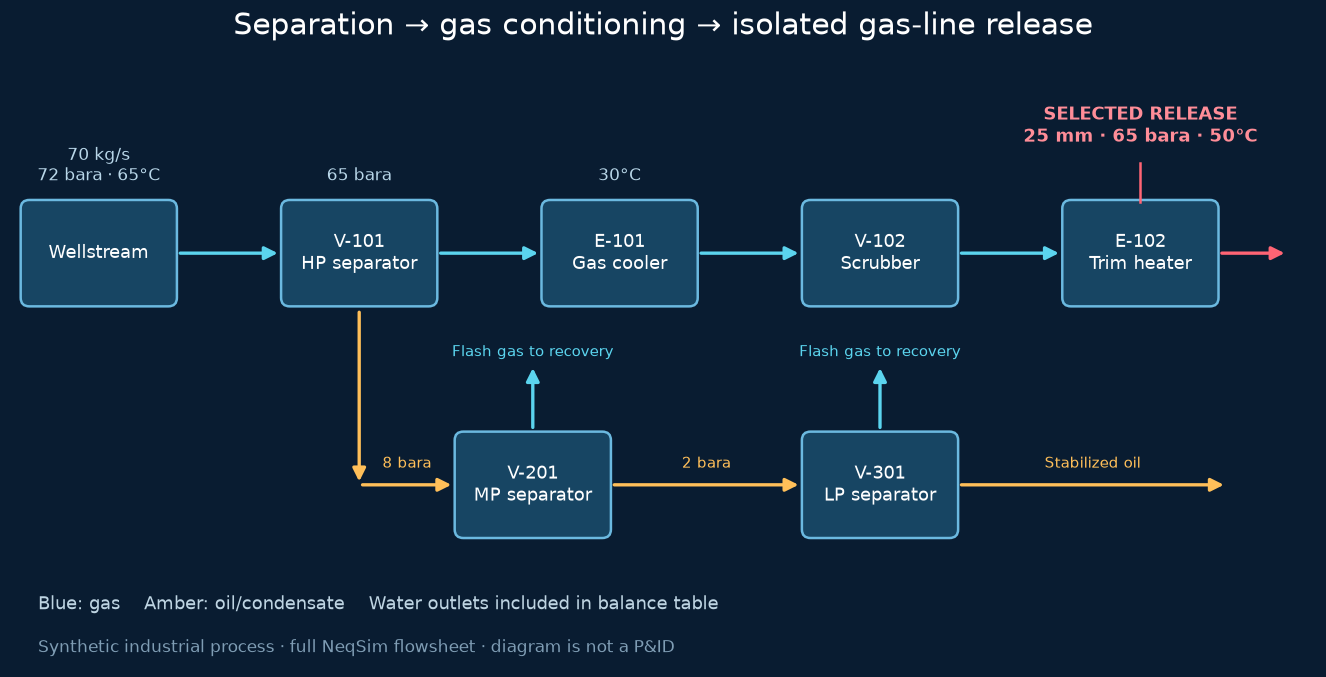

In [6]:
from IPython.display import Image, Markdown, display

style()
process, release_stream, stream_table, process_checks, feed_composition = build_process()
display(stream_table.round(5))
display(pd.DataFrame(process_checks.items(), columns=["Check / duty", "Value"]))
process_diagram(stream_table, figures_dir / "process.png")
plt.show()
stream_table.to_csv(results_dir / "process-streams.csv", index=False)

## 3 · Native scenario generation and an auditable isolation envelope

The generator is attached to a **one-stream ProcessSystem view of the selected gas envelope**.
Scanning every plant stream with one inventory would incorrectly assign the same blocked-in volume
to gas, oil and water releases. The complete plant remains available as `process`; the gas stream is
the actual calculated outlet object.

The native JSON and OpenFOAM skeleton are exported for inspection. Their validation checks the
handoff schema, not safety-model accuracy. The inventory's missing-document warnings are retained:
these geometry inputs are assumptions, not fabricated P&ID evidence.

The CFD uses the EOS-consistent mass initialized by `ReleaseInventory` for the specified volume. The geometry calculator's separate screening mass is retained as metadata and does not override that inventory state.

In [7]:
inventory = inventory_basis(release_stream)
native_case_data, native_case = screening_cases(release_stream, inventory)
inventory_data = json.loads(str(inventory.toJson()))
(results_dir / "native-screening-case.json").write_text(json.dumps(native_case_data, indent=2))
(results_dir / "inventory-basis.json").write_text(json.dumps(inventory_data, indent=2))
exporter = J("neqsim.process.safety.cfd.CfdSourceTermExporter")()
exporter.exportOpenFoamSkeleton(native_case, str(results_dir / "native-openfoam-skeleton"))
print("Native case schema validation:", native_case.validate().isValid())
print("Native JSON sections:", list(native_case_data))
print(json.dumps(inventory_data, indent=2))

Native case schema validation: True
Native JSON sections: ['schemaVersion', 'caseId', 'scenarioName', 'context', 'fluid', 'release', 'sourceTerm', 'ambient', 'dispersionScreening', 'inventory', 'consequenceBranches', 'cfdHints', 'provenance', 'qualityWarnings']
{
  "pressureBara": 65.0,
  "temperatureK": 323.15,
  "gasDensityKgPerM3": 56.20500293195273,
  "liquidDensityKgPerM3": 800.0,
  "totalVolumeM3": 23.999999999999762,
  "totalGasVolumeM3": 23.999999999999762,
  "totalLiquidVolumeM3": 0.0,
  "totalGasMassKg": 1348.920070366852,
  "totalLiquidMassKg": 0.0,
  "totalMassKg": 1348.920070366852,
  "segments": [
    {
      "segmentId": "Gas header and heater section",
      "type": "equipment",
      "totalVolumeM3": 16.0,
      "gasVolumeM3": 16.0,
      "liquidVolumeM3": 0.0,
      "gasMassKg": 899.2800469112436,
      "liquidMassKg": 0.0,
      "totalMassKg": 899.2800469112436,
      "gasDensityKgPerM3": 56.20500293195273,
      "liquidDensityKgPerM3": 800.0,
      "liquidFillFracti

## 4 · Choose the release physics explicitly

Three model boundaries must be kept separate:

1. The documented generator uses historical `LeakModel` screening. Its time-dependent pressure
   update compounds the cumulative mass ratio, giving a timestep-dependent trajectory. Reproduction
   and a repair request are recorded in [NeqSim #3905](https://github.com/equinor/neqsim/issues/3905).
   **Its blowdown history is not used to drive this CFD.**
2. The homogeneous-equilibrium atmospheric calculation for this CO₂-containing mixture returns
   `UNSUPPORTED` when an expansion sample falls below its CO₂ solid-risk guard. This is retained as
   a failed applicability check. A separate 10 bara receiving-pressure calculation is shown solely
   as a throat/rate comparison; it does not validate discharge to atmosphere.
3. The demonstrated CFD uses the native **IdealGasReleaseModel** rate/throat approximation, coupled
   to **ReleaseInventory** for conservative SRK gas-inventory mass and energy depletion. This
   approximates choking with the upstream heat-capacity ratio, omits real-gas nozzle/phase-change
   effects, and remains unqualified. Full equilibrium source qualification is a prerequisite for
   using this case for design, even if its rate happens to agree with the bounded comparison.

The physical opening thrust includes pressure thrust:

$$J=\dot m_f u_t+(p_t-p_a)C_d A_h.$$

Here $J$ is axial momentum flux [N], $\dot m_f$ released-mixture mass flow [kg/s], $u_t$ throat
velocity [m/s], $p_t$ throat pressure [Pa absolute], $p_a$ atmospheric pressure [Pa absolute],
$C_d$ discharge coefficient and $A_h$ physical hole area [m²]. Applying $C_d$ to pressure-thrust
area assumes a vena-contracta area; this is a source-model uncertainty.

### Native NeqSim master → CFD input

The selected `ReleaseFlowRequest` / `IdealGasReleaseModel` and `ReleaseInventory` are native
NeqSim classes. Every calculated state is packaged by **`SourceTermFrame.calculated(...)`**,
located in the deck coordinate frame, and exported to `neqsim-source-frames.ndjson`.
The adapter reads that file back, verifies native fingerprints and the JSON Schema shipped
in the loaded JAR, rejects unusable statuses, and checks SI units before creating boundaries.
The source rates are therefore NeqSim framework outputs, rather than a Python leak correlation.

| Native input | CFD use |
|---|---|
| `source.massFlowRate` | Released-gas mass rate before air entrainment |
| `source.advectiveMomentumRate` and throat/ambient pressure | Pressure-inclusive axial thrust |
| Upstream specific enthalpy and composition | Reference-consistent fuel enthalpy and mixture properties |
| `simulationTime` | Release time; shifted by the documented ventilation startup and ramp |
| Status, diagnostics, model, provenance and fingerprint | Validation and traceable case input |

`ReleaseDispersionScenarioGenerator` and `CfdSourceTermExporter` still demonstrate the documented
screening/case-registration layer. Their legacy time series is kept separate from the model-explicit
native frames used for the solver. The native contract carries **advective momentum only**;
the adapter explicitly adds the pressure-thrust term. Export is one-way/offline, not live coupling.


{
  "full_equilibrium_status": "UNSUPPORTED",
  "full_equilibrium_diagnostics": [
    {
      "code": "UNSUPPORTED_PHYSICS",
      "message": "CO2 below 216.592 K requires a separately assessed solid-capable model"
    }
  ],
  "10_bara_comparison_status": "VALID_WITH_WARNINGS",
  "10_bara_comparison_rate_kg_s": 3.8310706510019834,
  "10_bara_comparison_stations": [
    {
      "station": "UPSTREAM_STAGNATION",
      "P_bara": 65.0,
      "T_K": 323.15,
      "gas_mass_fraction": 1.0
    },
    {
      "station": "THROAT_CRITICAL",
      "P_bara": 36.58310085142158,
      "T_K": 285.65836090255607,
      "gas_mass_fraction": 0.9786565645454195
    },
    {
      "station": "ORIFICE_EXIT",
      "P_bara": 36.58310085142158,
      "T_K": 285.65836090255607,
      "gas_mass_fraction": 0.9786565645454195
    },
    {
      "station": "AMBIENT_EXPANDED",
      "P_bara": 10.0,
      "T_K": 226.3887591053139,
      "gas_mass_fraction": 0.8882771300436924
    }
  ]
}
Native handoff: 31 schema-

,time_s,rate_kg_s,thrust_N,temperature_K,upstream_temperature_K,pressure_bara,throat_temperature_K,released_from_inventory_kg
0,0.0,3.80314,2497.50150,289.33644,323.15000,65.00000,260.19433,0.00000
5,5.0,3.80314,2497.50150,289.33644,323.15000,65.00000,260.19433,0.00000
10,10.0,3.74011,2450.36106,288.22506,321.77673,63.78898,259.10432,18.87334
20,20.0,3.61787,2359.21961,286.03081,319.05645,61.44795,256.95209,55.68963
30,30.0,3.50050,2272.07006,283.87325,316.37043,59.20987,254.83557,91.30687


,Inventory check,Value
0,inventory_initial_kg,1.343921e+03
1,inventory_released_kg,9.130687e+01
2,component_closure_kg,3.623768e-13
3,energy_closure_J,-4.076348e-02
4,volume_m3,2.400000e+01


**Release-model diagnostics**

,code,message
0,IDEAL_GAS_ASSUMPTIONS,"Calorically perfect gas, constant gamma, isentropic acceleration; no real-gas departure or phase change"
1,NO_PROPERTY_FALLBACK,Mixture molar mass and gamma are required NeqSim properties; no default is substituted
2,EXIT_ALIASES_THROAT,Zero-length opening: exit equals accepted throat


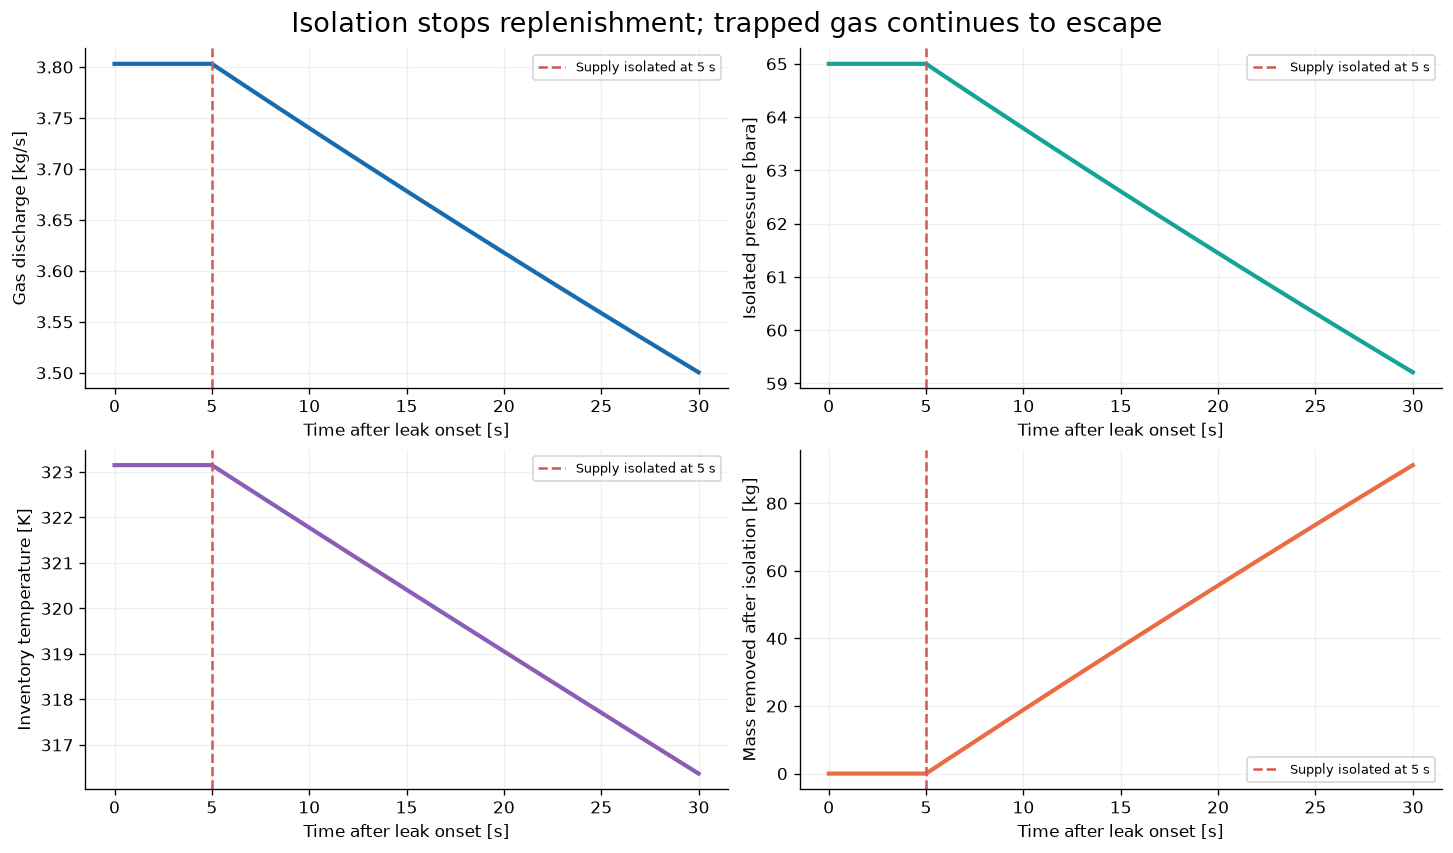

In [8]:
import jsonschema

pd.options.display.max_colwidth = None

schema_member = "neqsim/process/safety/release/schema/safety-source-term.schema.json"
with zipfile.ZipFile(source_jar) as jar:
    source_schema = json.loads(jar.read(schema_member))
source_schema_validator = jsonschema.Draft202012Validator(source_schema)
audit = source_model_audit(release_stream)
print(json.dumps(audit, indent=2))
records, gas_mw, gas_cp, inventory_checks, native_frames = source_history(release_stream)
native_frame_path = results_dir / "neqsim-source-frames.ndjson"
native_frame_path.write_text("\n".join(native_frames) + "\n")
(results_dir / "safety-source-term.schema.json").write_text(json.dumps(source_schema, indent=2))
# Read the saved native export back: these records are the actual CFD adapter input.
saved_frames = native_frame_path.read_text().splitlines()
records = [
    source_record_from_frame(frame, row["released_from_inventory_kg"])
    for frame, row in zip(saved_frames, records, strict=True)
]
history = pd.DataFrame(records)
display(history.iloc[[0, 5, 10, 20, 30]].round(5))
display(pd.DataFrame(inventory_checks.items(), columns=["Inventory check", "Value"]))
first_frame = json.loads(saved_frames[0])
print("Native handoff:", len(saved_frames), "schema-validated and fingerprint-verified frames")
print("Schema:", first_frame["schemaVersion"])
print("Model:", first_frame["model"])
display(Markdown("**Release-model diagnostics**"))
display(pd.DataFrame(first_frame["diagnostics"]))
source_figure(history, figures_dir / "source-history.png")
plt.show()
history.to_csv(results_dir / "source-history.csv", index=False)

The inventory conserves each component and removes the discharged upstream enthalpy. Before
isolation, a maintained upstream state is a defined boundary assumption; it is not a simulation
of the upstream well or controller. After isolation the gas-only section has no inflow, no heat
transfer and no connection to separator liquids. The hole remains open.

The exported `temperature_K` is an **enthalpy-equivalent CFD fuel temperature**, not the vessel
temperature. The reference translates SRK stagnation enthalpy into the CFD constant-heat-capacity
reference at 1 atm and 10°C. Vessel, throat and equivalent temperatures are separately named.
The ideal adapter's very cold unmixed ambient-expanded station is not imposed on the coarse CFD inlet.

The next cell independently evaluates the choked-gas equation and ranks opening/coefficient combinations. Only the 25 mm, Cd = 0.62 case is passed to CFD. Agreement checks implementation consistency, not physical accuracy at 65 bara.

Independent choked-equation rate [kg/s]: 3.8031386875694086
Relative difference to native ideal model: 9.215517238203574e-12


,5,10,25,50
Cd / hole [mm],,,,
0.50,0.122682,0.490728,3.067047,12.268189
0.62,0.152126,0.608502,3.803139,15.212555
0.80,0.196291,0.785164,4.907276,19.629103


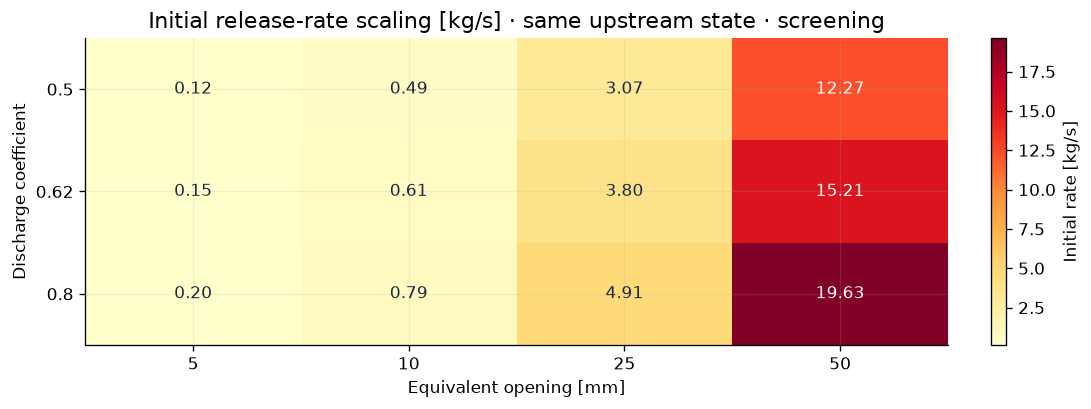

In [9]:
fluid_for_check = release_stream.getFluid().clone()
fluid_for_check.init(3)
gamma = float(fluid_for_check.getGamma())
critical_factor = (2 / (gamma + 1)) ** ((gamma + 1) / (2 * (gamma - 1)))
area_hole = np.pi * 0.025**2 / 4
reference_rate = (
    0.62 * area_hole * 65e5 * np.sqrt(gamma * gas_mw / (8.314462618 * 323.15)) * critical_factor
)
relative_error = abs(reference_rate / history.rate_kg_s.iloc[0] - 1)
assert relative_error < 1e-6
print("Independent choked-equation rate [kg/s]:", reference_rate)
print("Relative difference to native ideal model:", relative_error)
holes = np.array([5, 10, 25, 50])
coefficients = np.array([0.50, 0.62, 0.80])
rate_matrix = reference_rate * (holes[None, :] / 25) ** 2 * coefficients[:, None] / 0.62
display(pd.DataFrame(rate_matrix, index=coefficients, columns=holes).rename_axis("Cd / hole [mm]"))
fig, ax = plt.subplots(figsize=(9, 3.3), constrained_layout=True)
im = ax.imshow(rate_matrix, cmap="YlOrRd", aspect="auto")
ax.set(
    xticks=range(4),
    xticklabels=holes,
    yticks=range(3),
    yticklabels=coefficients,
    xlabel="Equivalent opening [mm]",
    ylabel="Discharge coefficient",
    title="Initial release-rate scaling [kg/s] · same upstream state · screening",
)
for i in range(3):
    for j in range(4):
        ax.text(
            j,
            i,
            f"{rate_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="white" if rate_matrix[i, j] > 10 else "#1c2740",
        )
fig.colorbar(im, ax=ax, label="Initial rate [kg/s]")
fig.savefig(figures_dir / "source-scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# A meaningful temporal check on the new conservative inventory path.
half_records, _, _, half_checks, _ = source_history(release_stream, substep=0.25)
half_history = pd.DataFrame(half_records)
inventory_sensitivity = pd.DataFrame(
    {
        "Internal step [s]": [0.5, 0.25],
        "Final pressure [bara]": [
            history.pressure_bara.iloc[-1],
            half_history.pressure_bara.iloc[-1],
        ],
        "Released inventory [kg]": [
            inventory_checks["inventory_released_kg"],
            half_checks["inventory_released_kg"],
        ],
    }
)
display(inventory_sensitivity)
assert abs(half_history.pressure_bara.iloc[-1] / history.pressure_bara.iloc[-1] - 1) < 0.002

,Internal step [s],Final pressure [bara],Released inventory [kg]
0,0.50,59.209870,91.306872
1,0.25,59.212712,91.270779


## 5 · A conservative far-field source, rather than a 25 mm hole on a 0.5 m mesh

The 1 m² control surface represents the jet **after unresolved expansion and entrainment**.
The real hole, shocks, droplets and near-field jet are outside the resolved CFD domain. The adapter
adds entrained air and solves simultaneously for mixed mass flow, velocity, temperature and density:

$$\dot m_m=\rho_m A_s U_s,\quad Y_f=\dot m_f/\dot m_m,\quad J=\dot m_m U_s.$$

$$\dot m_f c_{p,f}T_f^*+(\dot m_m-\dot m_f)c_{p,a}T_a=(\dot m_f c_{p,f}+\dot m_a c_{p,a})T_s+\tfrac12\dot m_m U_s^2.$$

The symbols $\dot m_m$ and $\dot m_a$ denote mixed and entrained-air rates [kg/s], $Y_f$ the
released-mixture mass fraction, $\rho_m$ density [kg/m³], $A_s$ control-surface area [m²],
$U_s$ velocity [m/s], $c_p$ heat capacity [J/(kg K)], and $T$ temperature [K].
$T_f^*$ is the SRK-to-CFD enthalpy-equivalent fuel temperature. The ideal mixture EOS closes density.

Mass, axial momentum and energy match **within this adopted mapping model**. Entrainment magnitude,
source area/stand-off, top-hat profile and turbulence remain unvalidated closure assumptions.
The 1 m² source is drawn as a virtual port; it is not the actual hole size. Injected entrained air
is not removed elsewhere in the CFD domain, so the unresolved near-field entrainment region is
replaced by this control-surface boundary. A qualified nozzle/entrainment model or a resolved
compressible near-field domain is needed for final studies.

In [11]:
"""NeqSim boundary records to a reproducible OpenFOAM v1912 dispersion case.

Educational, unqualified far-field RANS model. No chemistry or ignition.
"""

from pathlib import Path
import json
import os
import subprocess
import time

import numpy as np
from scipy.optimize import root


def header(name, cls="dictionary"):
    return "FoamFile\n{\nversion 2.0;\nformat ascii;\n" f"class {cls};\nobject {name};\n}}\n"


def write(case, relative, body, cls="dictionary"):
    path = Path(case) / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(header(path.name, cls) + body)


def solid(x, y, z):
    # Cylindrical vessels along y, a cooler skid and resolved rack columns.
    vessel = ((x + 1.5) ** 2 + (z - 2.5) ** 2 < 1.25**2) & (abs(y) < 3)
    scrubber = ((x + 3.5) ** 2 + (y - 4) ** 2 < 1.0**2) & (z < 5)
    skid = (x > 7) & (x < 10) & (y > -3) & (y < -1) & (z < 2)
    rack = (x > 12) & (x < 13) & (abs(y) > 2) & (abs(y) < 3) & (z < 5)
    beam = (x > 12) & (x < 13) & (abs(y) < 3) & (z > 4) & (z < 5)
    # Entrainment control surface represented by a 1 m2 port, not a resolved hole.
    nozzle = (x >= 0) & (x < 1) & (y >= 0) & (y < 1) & (z >= 3) & (z < 4)
    return vessel | scrubber | skid | rack | beam | nozzle


def create_mesh(case, spacing=0.5, domain_xmax=24.0):
    """Cartesian finite-volume mesh with explicit solid-cell removal and wall faces."""
    xs = np.arange(-6, domain_xmax + spacing / 2, spacing)
    ys = np.arange(-6, 6 + spacing / 2, spacing)
    zs = np.arange(0, 9 + spacing / 2, spacing)
    shape = (len(xs) - 1, len(ys) - 1, len(zs) - 1)
    centres = np.stack(
        np.meshgrid(
            (xs[:-1] + xs[1:]) / 2,
            (ys[:-1] + ys[1:]) / 2,
            (zs[:-1] + zs[1:]) / 2,
            indexing="ij",
        ),
        axis=-1,
    )
    active = ~solid(*np.moveaxis(centres, -1, 0))
    labels = np.full(shape, -1, dtype=int)
    labels[active] = np.arange(active.sum())
    points = np.stack(np.meshgrid(xs, ys, zs, indexing="ij"), axis=-1).reshape(-1, 3)

    def point(i, j, k):
        return (i * len(ys) + j) * len(zs) + k

    patterns = [
        [(0, 0, 0), (0, 0, 1), (0, 1, 1), (0, 1, 0)],
        [(1, 0, 0), (1, 1, 0), (1, 1, 1), (1, 0, 1)],
        [(0, 0, 0), (1, 0, 0), (1, 0, 1), (0, 0, 1)],
        [(0, 1, 0), (0, 1, 1), (1, 1, 1), (1, 1, 0)],
        [(0, 0, 0), (0, 1, 0), (1, 1, 0), (1, 0, 0)],
        [(0, 0, 1), (1, 0, 1), (1, 1, 1), (0, 1, 1)],
    ]
    offsets = [(-1, 0, 0), (1, 0, 0), (0, -1, 0), (0, 1, 0), (0, 0, -1), (0, 0, 1)]
    boundaries = {
        key: [] for key in ["inlet", "outlet", "sides", "top", "ground", "walls", "release"]
    }
    internal = []
    for i, j, k in np.argwhere(active):
        owner = int(labels[i, j, k])
        for direction, (di, dj, dk) in enumerate(offsets):
            adjacent = (i + di, j + dj, k + dk)
            inside = all(0 <= v < n for v, n in zip(adjacent, shape))
            neighbour = int(labels[adjacent]) if inside else -1
            if neighbour >= 0 and neighbour < owner:
                continue
            vertices = [point(i + a, j + b, k + c) for a, b, c in patterns[direction]]
            face = (vertices, owner, neighbour)
            if neighbour >= 0:
                internal.append(face)
            else:
                if not inside:
                    patch = ["inlet", "outlet", "sides", "sides", "ground", "top"][direction]
                else:
                    fc = points[vertices].mean(axis=0)
                    release = (
                        direction == 0 and abs(fc[0] - 1) < 1e-8 and 0 < fc[1] < 1 and 3 < fc[2] < 4
                    )
                    patch = "release" if release else "walls"
                boundaries[patch].append(face)
    internal.sort(key=lambda face: (face[1], face[2]))
    faces = internal + [f for group in boundaries.values() for f in group]
    used = np.unique(np.concatenate([np.asarray(face[0]) for face in faces]))
    remap = np.full(len(points), -1, dtype=int)
    remap[used] = np.arange(len(used))
    points = points[used]
    faces = [(remap[face[0]].tolist(), face[1], face[2]) for face in faces]
    write(
        case,
        "constant/polyMesh/points",
        f"{len(points)}\n(\n"
        + "\n".join("(" + " ".join(f"{v:.9g}" for v in p) + ")" for p in points)
        + "\n)\n",
        "vectorField",
    )
    write(
        case,
        "constant/polyMesh/faces",
        f"{len(faces)}\n(\n"
        + "\n".join("4(" + " ".join(map(str, f[0])) + ")" for f in faces)
        + "\n)\n",
        "faceList",
    )
    for name, records, column in [("owner", faces, 1), ("neighbour", internal, 2)]:
        write(
            case,
            "constant/polyMesh/" + name,
            f"{len(records)}\n(\n" + "\n".join(str(f[column]) for f in records) + "\n)\n",
            "labelList",
        )
    start = len(internal)
    patch_text = []
    for name, group in boundaries.items():
        kind = "wall" if name in ["ground", "walls"] else "patch"
        patch_text.append(f"{name}\n{{ type {kind}; nFaces {len(group)}; startFace {start}; }}")
        start += len(group)
    write(
        case,
        "constant/polyMesh/boundary",
        f"{len(boundaries)}\n(\n" + "\n".join(patch_text) + "\n)\n",
        "polyBoundaryMesh",
    )
    metadata = {
        "cells": int(active.sum()),
        "spacing_m": spacing,
        "release_area_m2": len(boundaries["release"]) * spacing**2,
        "patch_faces": {k: len(v) for k, v in boundaries.items()},
        "volume_m3": float(active.sum() * spacing**3),
    }
    np.savez_compressed(
        Path(case) / "mesh-data.npz",
        centres=centres[active],
        solid_centres=centres[~active],
        cell_volume=spacing**3,
    )
    (Path(case) / "mesh-metadata.json").write_text(json.dumps(metadata, indent=2))
    return metadata


def mix_source(rate, thrust, temperature, molecular_weight, cp, area=1, ambient=283.15):
    """Match fuel mass, axial momentum and total sensible-enthalpy flux at 1 atm."""
    air_cp = 1005.0
    air_mw = 0.028965

    def residual(state):
        mass, temp = state
        velocity = thrust / mass
        fraction = rate / mass
        mw = 1 / (fraction / molecular_weight + (1 - fraction) / air_mw)
        density = 101325 * mw / (8.314462618 * temp)
        energy_in = rate * cp * temperature + (mass - rate) * air_cp * ambient
        energy_out = (rate * cp + (mass - rate) * air_cp) * temp + mass * velocity**2 / 2
        return [mass - density * area * velocity, (energy_out - energy_in) / 10000]

    solved = root(residual, [np.sqrt(thrust * 1.2 * area), ambient])
    if not solved.success:
        raise RuntimeError(solved.message)
    mass, temp = solved.x
    assert mass > rate > 0 and 220 < temp < 400
    speed = thrust / mass
    return {
        "U_ms": float(speed),
        "T_K": float(temp),
        "Y_fuel": float(rate / mass),
        "mixture_kg_s": float(mass),
        "entrained_air_kg_s": float(mass - rate),
        "fuel_kg_s": float(rate),
        "thrust_N": float(thrust),
        "mapping_residual": float(np.max(np.abs(residual(solved.x)))),
    }


def time_boundary(rows, column, vector=False):
    pairs = []
    for row in rows:
        value = f"({row[column]:.12g} 0 0)" if vector else f"{row[column]:.12g}"
        pairs.append(f"({row['time_s']:.10g} {value})")
    initial = f"({rows[0][column]:.12g} 0 0)" if vector else f"{rows[0][column]:.12g}"
    return (
        "type uniformFixedValue;\nuniformValue table\n(\n"
        + "\n".join(pairs)
        + f"\n);\nvalue uniform {initial};\n"
    )


def create_case(
    case,
    records,
    molecular_weight,
    cp,
    spacing=0.5,
    wind=3.0,
    end=25.0,
    max_co=0.8,
    domain_xmax=24.0,
):
    case = Path(case)
    case.mkdir(parents=True, exist_ok=True)
    mesh = create_mesh(case, spacing, domain_xmax)
    assert abs(mesh["release_area_m2"] - 1) < 1e-10
    rows = []
    for record in records:
        mapped = mix_source(
            record["rate_kg_s"], record["thrust_N"], record["temperature_K"], molecular_weight, cp
        )
        mapped["time_s"] = record["time_s"] + 5.05
        mapped["k"] = 1.5 * (0.05 * mapped["U_ms"]) ** 2
        mapped["epsilon"] = 0.09**0.75 * mapped["k"] ** 1.5 / 0.07
        rows.append(mapped)
    quiet = dict(rows[0])
    quiet.update(
        U_ms=0.0,
        Y_fuel=0.0,
        T_K=283.15,
        k=0.001,
        epsilon=0.001,
        mixture_kg_s=0.0,
        entrained_air_kg_s=0.0,
        fuel_kg_s=0.0,
        thrust_N=0.0,
        mapping_residual=0.0,
    )
    rows = [{**quiet, "time_s": 0.0}, {**quiet, "time_s": 5.0}] + rows
    (case / "source-boundary.json").write_text(json.dumps(rows, indent=2))
    write(
        case,
        "constant/thermophysicalProperties",
        f"""
thermoType
{{ type heRhoThermo; mixture reactingMixture; transport const;
   thermo hConst; energy sensibleEnthalpy; equationOfState perfectGas; specie specie; }}
inertSpecie air;
chemistryReader foamChemistryReader;
foamChemistryFile "<constant>/reactions";
foamChemistryThermoFile "<constant>/thermo";
dpdt false;
""",
    )
    write(case, "constant/reactions", "species (fuel air);\nreactions {}\n")
    species = []
    for name, mw, heat, mu in [
        ("fuel", molecular_weight * 1000, cp, 1.2e-5),
        ("air", 28.965, 1005, 1.8e-5),
    ]:
        species.append(f"""{name}
{{ specie {{ molWeight {mw}; }} thermodynamics {{ Cp {heat}; Hf 0; }}
transport {{ mu {mu}; Pr 0.7; }} }}""")
    write(case, "constant/thermo", "\n".join(species))
    write(case, "constant/combustionProperties", "combustionModel none;\n")
    write(
        case,
        "constant/chemistryProperties",
        "chemistryType { chemistrySolver ode; chemistryThermo rho; }\nchemistry off; initialChemicalTimeStep 1e-7;\nodeCoeffs { solver Rosenbrock34; absTol 1e-12; relTol 1e-7; }\n",
    )
    write(
        case,
        "constant/g",
        "dimensions [0 1 -2 0 0 0 0];\nvalue (0 0 -9.81);\n",
        "uniformDimensionedVectorField",
    )
    write(
        case,
        "constant/turbulenceProperties",
        "simulationType RAS;\nRAS { RASModel kEpsilon; turbulence on; printCoeffs on; }\n",
    )
    write(case, "constant/radiationProperties", "radiationModel none;\n")
    write(case, "constant/thermophysicalTransport", "")
    write(
        case,
        "system/controlDict",
        f"""
application rhoReactingBuoyantFoam;
startFrom startTime; startTime 0; stopAt endTime; endTime {end};
deltaT 0.002; adjustTimeStep yes; maxCo {max_co}; maxDeltaT 0.05;
writeControl adjustableRunTime; writeInterval 0.5; purgeWrite 0;
writeFormat ascii; writePrecision 10; writeCompression off;
timeFormat general; timePrecision 9; runTimeModifiable false;
functions
{{
 detectors
 {{ type probes; libs ("libsampling.so"); writeControl timeStep; writeInterval 10;
    fields (fuel U T); probeLocations ((4 0.5 3.5) (8 0.5 3.5) (16 0.5 3.5) (8 3 1.5)); }}
}}
""",
    )
    write(
        case,
        "system/fvSchemes",
        """
ddtSchemes { default Euler; }
gradSchemes { default Gauss linear; grad(U) cellLimited Gauss linear 1; }
divSchemes
{
 default none;
 div(phi,U) Gauss limitedLinearV 1;
 div(phi,Yi) Gauss limitedLinear01 1;
 div(phi,h) Gauss limitedLinear 1;
 div(phi,K) Gauss limitedLinear 1;
 div(phid,p) Gauss limitedLinear 1;
 div(phi,k) Gauss upwind;
 div(phi,epsilon) Gauss upwind;
 div(phi,Yi_h) Gauss limitedLinear 1;
 div(((rho*nuEff)*dev2(T(grad(U))))) Gauss linear;
}
laplacianSchemes { default Gauss linear corrected; }
interpolationSchemes { default linear; }
snGradSchemes { default corrected; }
fluxRequired { default no; p_rgh; }
""",
    )
    write(
        case,
        "system/fvSolution",
        """
solvers
{
 "rho.*" { solver diagonal; }
 p_rgh { solver GAMG; tolerance 1e-7; relTol 0.01; smoother GaussSeidel; }
 p_rghFinal { $p_rgh; tolerance 1e-8; relTol 0; }
 "(U|h|k|epsilon)" { solver PBiCGStab; preconditioner DILU; tolerance 1e-7; relTol 0.05; }
 "(U|h|k|epsilon)Final" { solver PBiCGStab; preconditioner DILU; tolerance 1e-8; relTol 0; }
 Yi { solver PBiCGStab; preconditioner DILU; tolerance 1e-9; relTol 0; }
}
PIMPLE { momentumPredictor yes; nOuterCorrectors 2; nCorrectors 2;
 nNonOrthogonalCorrectors 0; pRefCell 0; pRefValue 101325; }
relaxationFactors { equations { ".*" 1; } }
""",
    )

    def field(name, dim, initial, boundaries, vector=False):
        body = f"dimensions [{dim}];\ninternalField uniform {initial};\nboundaryField\n{{\n"
        body += "\n".join(f"{p}\n{{ {b} }}" for p, b in boundaries.items()) + "\n}\n"
        write(case, "0/" + name, body, "volVectorField" if vector else "volScalarField")

    common = {k: "type zeroGradient;" for k in mesh["patch_faces"]}
    field(
        "U",
        "0 1 -1 0 0 0 0",
        f"({wind} 0 0)",
        {
            "inlet": f"type fixedValue; value uniform ({wind} 0 0);",
            "outlet": "type pressureInletOutletVelocity; value uniform (0 0 0);",
            "sides": "type pressureInletOutletVelocity; value uniform (0 0 0);",
            "top": "type pressureInletOutletVelocity; value uniform (0 0 0);",
            "ground": "type noSlip;",
            "walls": "type noSlip;",
            "release": time_boundary(rows, "U_ms", True),
        },
        True,
    )
    field(
        "p",
        "1 -1 -2 0 0 0 0",
        "101325",
        {k: "type calculated; value uniform 101325;" for k in common},
    )
    pbc = {k: "type fixedFluxPressure; value uniform 101325;" for k in common}
    for k in ["outlet", "sides", "top"]:
        pbc[k] = "type fixedValue; value uniform 101325;"
    field("p_rgh", "1 -1 -2 0 0 0 0", "101325", pbc)
    for name, initial, column, dimension in [
        ("fuel", 0, "Y_fuel", "0 0 0 0 0 0 0"),
        ("T", 283.15, "T_K", "0 0 0 1 0 0 0"),
    ]:
        bc = dict(common)
        for k in ["outlet", "sides", "top"]:
            bc[k] = f"type inletOutlet; inletValue uniform {initial}; value uniform {initial};"
        bc["inlet"] = f"type fixedValue; value uniform {initial};"
        bc["release"] = time_boundary(rows, column)
        field(name, dimension, str(initial), bc)
    field("air", "0 0 0 0 0 0 0", "1", {k: "type calculated; value uniform 1;" for k in common})
    wind_k = 1.5 * (0.1 * wind) ** 2
    wind_eps = 0.09**0.75 * wind_k**1.5 / 0.5
    for name, val, dim in [
        ("k", wind_k, "0 2 -2 0 0 0 0"),
        ("epsilon", wind_eps, "0 2 -3 0 0 0 0"),
    ]:
        bc = dict(common)
        for k in ["outlet", "sides", "top"]:
            bc[k] = f"type inletOutlet; inletValue uniform {val}; value uniform {val};"
        bc["inlet"] = f"type fixedValue; value uniform {val};"
        bc["release"] = time_boundary(rows, name)
        wall = "kqRWallFunction" if name == "k" else "epsilonWallFunction"
        for k in ["walls", "ground"]:
            bc[k] = f"type {wall}; value uniform {val};"
        field(name, dim, str(val), bc)
    for name, dim, wall in [
        ("nut", "0 2 -1 0 0 0 0", "nutkWallFunction"),
        ("alphat", "1 -1 -1 0 0 0 0", "compressible::alphatWallFunction"),
    ]:
        bc = {k: "type calculated; value uniform 0;" for k in common}
        for k in ["ground", "walls"]:
            bc[k] = f"type {wall}; value uniform 0;"
        field(name, dim, "0", bc)
    (case / "case.foam").touch()
    return mesh, rows


def foam_environment():
    env = os.environ.copy()
    env.setdefault("WM_PROJECT_DIR", "/usr/share/openfoam")
    env.setdefault("WM_PROJECT_VERSION", "v1912")
    env.setdefault("FOAM_ETC", "/usr/share/openfoam/etc")
    return env


def run_case(case):
    case = Path(case).resolve()
    start = time.monotonic()
    for command in ["checkMesh", "rhoReactingBuoyantFoam"]:
        with (case / f"log.{command}").open("w") as log:
            arguments = [command, "-case", str(case)]
            if command == "rhoReactingBuoyantFoam":
                arguments.append("-noFunctionObjects")
            result = subprocess.run(
                arguments, stdout=log, stderr=subprocess.STDOUT, env=foam_environment()
            )
        if result.returncode:
            print((case / f"log.{command}").read_text()[-5000:])
            raise RuntimeError(f"{command} failed: {result.returncode}")
        if command == "checkMesh" and "Mesh OK" not in (case / "log.checkMesh").read_text():
            raise RuntimeError("Mesh quality checks did not pass")
    elapsed = time.monotonic() - start
    (case / "runtime.json").write_text(json.dumps({"wall_seconds": elapsed}))
    return elapsed

In [12]:
mapped = [
    {
        "time_s": row["time_s"],
        **mix_source(row["rate_kg_s"], row["thrust_N"], row["temperature_K"], gas_mw, gas_cp),
    }
    for row in records
]
mapping_table = pd.DataFrame(mapped)
display(mapping_table.iloc[[0, 5, 10, 20, 30]].round(6))
assert mapping_table.mapping_residual.max() < 1e-5
mapping_table.to_csv(results_dir / "mapped-source.csv", index=False)

# Equilibrium phase audit at the first mixed inlet state, including entrained air.
first = mapped[0]
mixed = J("neqsim.thermo.system.SystemSrkEos")(first["T_K"], 1.01325)
gas_composition, mixture_lfl, mixture_ufl = lfl_basis(release_stream)
for name, fraction in gas_composition.items():
    mixed.addComponent(name, fraction * first["fuel_kg_s"] / gas_mw)
mixed.addComponent("nitrogen", 0.79 * first["entrained_air_kg_s"] / 0.028965)
mixed.addComponent("oxygen", 0.21 * first["entrained_air_kg_s"] / 0.028965)
mixed.setMixingRule("classic")
mixed.setMultiPhaseCheck(True)
J("neqsim.thermodynamicoperations.ThermodynamicOperations")(mixed).TPflash()
assert mixed.getNumberOfPhases() == 1
assert str(mixed.getPhase(0).getType()) == "GAS"
print("Initial entrained mixture: single gas phase at", round(first["T_K"], 2), "K")

Initial entrained mixture: single gas phase at 282.97 K


,time_s,U_ms,T_K,Y_fuel,mixture_kg_s,entrained_air_kg_s,fuel_kg_s,thrust_N,mapping_residual
0,0.0,45.394904,282.971028,0.069126,55.017221,51.214083,3.803139,2497.501504,0.0
5,5.0,45.394904,282.971028,0.069126,55.017221,51.214083,3.803139,2497.501504,0.0
10,10.0,44.949587,282.844197,0.068609,54.513539,50.773430,3.740109,2450.361059,0.0
20,20.0,44.077367,282.598835,0.067593,53.524513,49.906645,3.617869,2359.219609,0.0
30,30.0,43.228806,282.364075,0.066601,52.559167,49.058668,3.500500,2272.070060,0.0


## 6 · CFD model, mesh and boundary conditions

| Boundary/model | Specification |
|---|---|
| Wind inlet | Fixed horizontal velocity; 10% turbulence intensity; 0.5 m turbulence length scale |
| Release surface | Tabulated mixed velocity, fuel mass fraction, temperature, k and epsilon; 5% jet intensity; 0.07 m length scale |
| Outlet / lateral / top | Hydrostatic-reduced pressure p_rgh = 101325 Pa; pressure-compatible velocity; clean-air backflow |
| Deck / equipment | No-slip, adiabatic; standard k–epsilon wall functions |
| Gas thermodynamics | Two pseudo-species: fixed-composition released gas and air; ideal mixture EOS; constant Cp/transport |
| Species diffusion | Solver's effective diffusivity, with default turbulent heat/species analogy; no calibrated Schmidt model |
| Temporal / convection | Implicit Euler; bounded limited-linear scalar convection; two outer and two pressure correctors |
| Startup | Five seconds of wind-flow development, followed by a 0.05 s source ramp; startup independence not established |
| Sampling | Every 0.5 s; virtual detectors extracted at reported cell centers |

The Cartesian mesh gives orthogonal cells and explicitly resolved large obstacles, but stair-steps
curved vessels and omits small pipes, gratings and supports. This is a **workflow and numerical
sensitivity demonstration**, not a mesh-converged industrial congestion model. A real study should
use surveyed CAD, assessed simplification, an atmospheric boundary layer consistent with surface
roughness and turbulence, additional directions/stability classes, and longer domain/startup tests.

The packaged v1912 build has an old function-object dictionary hashing incompatibility with some
modern C++ runtimes. The solver runs with `-noFunctionObjects`; probes and budgets are reconstructed
from saved fields. No simulation equations are disabled.

The open boundaries hold hydrostatic-reduced pressure, $p_{rgh}=p-\rho\,\mathbf{g}\cdot\mathbf{x}$. This supplies the atmospheric pressure gradient under gravity. Setting the same absolute static pressure at every elevation creates an unphysical background acceleration. The pre-release velocity field is checked explicitly. See [OpenFOAM hydrostatic pressure formulation](https://doc.openfoam.com/2212/tools/processing/solvers/algorithm-p-rgh/).

### What the notebook writes for each runnable case

| Case path | Purpose |
|---|---|
| `constant/polyMesh/` | Complete points, faces, owner/neighbour connectivity and named patches |
| `0/U`, `0/fuel`, `0/T`, `0/k`, `0/epsilon` | Initial fields and tabulated NeqSim-derived release boundary |
| `0/p`, `0/p_rgh`, `0/air`, `0/nut`, `0/alphat` | Pressure, remaining species and wall-function fields |
| `constant/thermophysicalProperties`, `constant/thermo`, `constant/reactions` | Gas/air thermodynamics and nonreacting species setup |
| `constant/turbulenceProperties`, `constant/combustionProperties`, `constant/g` | RANS closure, chemistry disabled and gravity |
| `system/controlDict` | Solver, 25 s end time, adaptive timestep and 0.5 s output interval |
| `system/fvSchemes`, `system/fvSolution` | Discretization, linear solvers and PIMPLE controls |
| `source-boundary.json`, `mesh-metadata.json`, `mesh-data.npz` | Auditable source mapping and geometry metadata |
| `log.checkMesh`, `log.rhoReactingBuoyantFoam`, `runtime.json` | Mesh quality, solver convergence/continuity and timing evidence |

The mesh writer below creates the complete `polyMesh` directly; this particular workflow does
not require `blockMesh` or `snappyHexMesh`. Change the `solid(...)` layout, `case_settings` mesh
spacing/wind/domain, or the native source configuration, then rerun from that section onward.
Change release duration together with the solver end time and postprocessing times.


In [13]:
case_settings = {
    "base": {"spacing": 0.5, "wind": 3.0, "max_co": 0.5},
    "coarse": {"spacing": 1.0, "wind": 3.0, "max_co": 0.5},
    "time_step": {"spacing": 1.0, "wind": 3.0, "max_co": 0.25},
    "fast_wind": {"spacing": 1.0, "wind": 6.0, "max_co": 0.5},
    "long_domain": {"spacing": 1.0, "wind": 3.0, "max_co": 0.5, "domain_xmax": 60.0},
}
case_root = results_dir / "OpenFOAM"
mesh_records = []
for settings in case_settings.values():
    settings.setdefault("domain_xmax", 24.0)
for name, settings in case_settings.items():
    mesh, boundary_rows = create_case(case_root / name, records, gas_mw, gas_cp, **settings)
    mesh_records.append(
        {
            "Case": name,
            **settings,
            "cells": mesh["cells"],
            "source area [m2]": mesh["release_area_m2"],
        }
    )
display(pd.DataFrame(mesh_records))

,Case,spacing,wind,max_co,domain_xmax,cells,source area [m2]
0,base,0.5,3.0,0.50,24.0,25392,1.0
1,coarse,1.0,3.0,0.50,24.0,3173,1.0
2,time_step,1.0,3.0,0.25,24.0,3173,1.0
3,fast_wind,1.0,6.0,0.50,24.0,3173,1.0
4,long_domain,1.0,3.0,0.50,60.0,7061,1.0


**Run policy.** By default the next cell runs all five cases. All five solutions were freshly
computed for this revision. The final display/movie pass reused those solved fields through
`OPENFOAM_VALIDATED_RUN`, after checking every generated input byte and all stored output/log
hashes. Reuse is recorded in the table below; process calculations and postprocessing still run
from a fresh Python process. Leave the environment variable unset for a complete fresh Colab run.

In [14]:
import hashlib
import time

validated_run = os.environ.get("OPENFOAM_VALIDATED_RUN")
execution_evidence = []
for name in case_settings:
    case_path = case_root / name
    if validated_run:
        previous = Path(validated_run) / name
        manifest = json.loads((previous / "verified-run.json").read_text())
        for relative, expected in manifest["sha256"].items():
            assert (
                hashlib.sha256((previous / relative).read_bytes()).hexdigest() == expected
            ), relative
        for subdir in ["0", "constant", "system"]:
            for input_file in (case_path / subdir).rglob("*"):
                if input_file.is_file():
                    relative = input_file.relative_to(case_path)
                    assert input_file.read_bytes() == (previous / relative).read_bytes(), relative
        assert (case_path / "source-boundary.json").read_bytes() == (
            previous / "source-boundary.json"
        ).read_bytes()
        for output in previous.iterdir():
            if output.is_dir() and output.name.replace(".", "", 1).isdigit() and output.name != "0":
                shutil.copytree(output, case_path / output.name, dirs_exist_ok=True)
            elif output.name.startswith("log.") or output.name == "runtime.json":
                shutil.copy2(output, case_path / output.name)
        mode = "Input/output-hash-verified executed solution"
        elapsed = json.loads((case_path / "runtime.json").read_text())["wall_seconds"]
    else:
        elapsed = run_case(case_path)
        mode = "Solver executed in this run"
    assert "Mesh OK" in (case_path / "log.checkMesh").read_text()
    assert "\nEnd\n" in (case_path / "log.rhoReactingBuoyantFoam").read_text()
    execution_evidence.append({"Case": name, "Mode": mode, "Solver wall seconds": elapsed})
display(pd.DataFrame(execution_evidence))
for name in case_settings:
    runtime_record = json.loads((case_root / name / "runtime.json").read_text())
    if runtime_record.get("log_scope"):
        display(Markdown(f"**{name} log coverage:** {runtime_record['log_scope']}"))

,Case,Mode,Solver wall seconds
0,base,Input/output-hash-verified executed solution,685.419691
1,coarse,Input/output-hash-verified executed solution,49.089322
2,time_step,Input/output-hash-verified executed solution,94.727004
3,fast_wind,Input/output-hash-verified executed solution,50.865652
4,long_domain,Input/output-hash-verified executed solution,103.336522


## 7 · Convert the transported gas fraction to flammability metrics

OpenFOAM's `fuel` field is the mass fraction of the **entire released gas mixture**, including
CO₂, nitrogen and trace water. Component ratios stay fixed in the gas/air model. Its mole fraction is:

$$x_g=\frac{Y_f/M_g}{Y_f/M_g+(1-Y_f)/M_a}.$$

Here $M_g$ and $M_a$ are gas and air molar masses [kg/mol]. The screening mixture limit uses
Le Chatelier's relation with original released-gas mole fractions $z_i$:

$$x_{g,\mathrm{LFL}}=\left(\sum_{i\in\mathrm{combustible}}\frac{z_i}{\mathrm{LFL}_i}\right)^{-1}.$$

The component limits in `lfl_basis` are representative ambient-air assumptions. Propane, butane,
pentane and heptane sources are linked below; methane/ethane/decane values are explicitly listed
engineering assumptions. Trace-species effects, elevated-temperature limits and inerting require
a reviewed project basis. UFL mixing is only a screening approximation. The reported flammable
volume counts **LFL ≤ gas mole fraction ≤ UFL**; 50% LFL volume is reported separately.

In [15]:
"""Read computed OpenFOAM fields, audit fluxes and draw study figures."""

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.integrate import cumulative_trapezoid
from scipy.spatial import cKDTree
import pyvista as pv


def read_value(text, count, key="internalField"):
    expression = rf"\b{key}\s+(?:uniform\s+([^;]+)|nonuniform\s+List<\w+>\s+\d+\s*\((.*?)\)\s*;)"
    match = re.search(expression, text, re.S)
    if not match:
        return None
    if match.group(1) is not None:
        value = np.fromstring(match.group(1).replace("(", "").replace(")", ""), sep=" ")
        return np.full(count, value[0]) if value.size == 1 else np.tile(value, (count, 1))
    values = np.fromstring(match.group(2).replace("(", "").replace(")", ""), sep=" ")
    return values if values.size == count else values.reshape(count, -1)


def patch_block(text, name):
    match = re.search(rf"\b{re.escape(name)}\s*\{{", text)
    if not match:
        raise ValueError(f"Missing patch {name}")
    start = match.end()
    level = 1
    for end in range(start, len(text)):
        level += (text[end] == "{") - (text[end] == "}")
        if level == 0:
            return text[start:end]
    raise ValueError("Unbalanced field dictionary")


def mesh_owners(case, metadata):
    text = (case / "constant/polyMesh/owner").read_text()
    match = re.search(r"\n(\d+)\s*\((.*?)\)", text, re.S)
    owners = np.fromstring(match.group(2), sep=" ", dtype=int)
    total_boundary = sum(metadata["patch_faces"].values())
    start = len(owners) - total_boundary
    result = {}
    for name, count in metadata["patch_faces"].items():
        result[name] = owners[start : start + count]
        start += count
    return result


def mole_fraction(mass_fraction, mw):
    return (mass_fraction / mw) / (mass_fraction / mw + (1 - mass_fraction) / 0.028965)


def analyse_case(case, mw, lfl, ufl):
    case = Path(case)
    metadata = json.loads((case / "mesh-metadata.json").read_text())
    mesh = np.load(case / "mesh-data.npz")
    centres = mesh["centres"]
    volume = float(mesh["cell_volume"])
    count = len(centres)
    patch_owners = mesh_owners(case, metadata)
    times = sorted(
        (p for p in case.iterdir() if p.is_dir() and re.fullmatch(r"\d+(?:\.\d+)?", p.name)),
        key=lambda p: float(p.name),
    )
    detector_positions = np.array([[4, 0.5, 3.5], [8, 0.5, 3.5], [16, 0.5, 3.5], [8, 3, 1.5]])
    _, probe_index = cKDTree(centres).query(detector_positions)
    records = []
    for directory in times:
        time = float(directory.name)
        scalar = {}
        text = {}
        for name in ["fuel", "p", "T", "alphat"]:
            text[name] = (directory / name).read_text()
            scalar[name] = read_value(text[name], count)
        fuel = scalar["fuel"]
        xgas = mole_fraction(fuel, mw)
        mix_mw = 1 / (fuel / mw + (1 - fuel) / 0.028965)
        rho = scalar["p"] * mix_mw / (8.314462618 * scalar["T"])
        flammable = (xgas >= lfl) & (xgas <= ufl)
        above = xgas >= lfl
        half = xgas >= 0.5 * lfl
        record = {
            "time_s": time,
            "cloud_fuel_kg": float(np.sum(rho * fuel) * volume),
            "flammable_volume_m3": float(np.sum(flammable) * volume),
            "flammable_fuel_kg": float(np.sum((rho * fuel)[flammable]) * volume),
            "half_lfl_volume_m3": float(np.sum(half) * volume),
            "lfl_extent_m": (
                float(np.max(centres[above, 0]) + metadata["spacing_m"] / 2 - 1)
                if above.any()
                else 0
            ),
            "half_lfl_extent_m": (
                float(np.max(centres[half, 0]) + metadata["spacing_m"] / 2 - 1) if half.any() else 0
            ),
            "Y_min": float(fuel.min()),
            "Y_max": float(fuel.max()),
            "T_min_K": float(scalar["T"].min()),
            "T_max_K": float(scalar["T"].max()),
            "outlet_max_percent_LFL": float(100 * xgas[patch_owners["outlet"]].max() / lfl),
            "open_boundary_max_percent_LFL": float(
                100
                * max(xgas[patch_owners[k]].max() for k in ["inlet", "outlet", "sides", "top"])
                / lfl
            ),
        }
        for i, index in enumerate(probe_index):
            record[f"D{i + 1}_percent_LFL"] = float(100 * xgas[index] / lfl)
        net_outflow = 0.0
        source_inflow = 0.0
        if time > 0:
            phi_text = (directory / "phi").read_text()
            for patch, owners in patch_owners.items():
                n = len(owners)
                phi = read_value(patch_block(phi_text, patch), n, "value")
                if phi is None:
                    raise ValueError("Flux patch has no value")
                yb = read_value(patch_block(text["fuel"], patch), n, "value")
                yb = fuel[owners] if yb is None else yb
                at = read_value(patch_block(text["alphat"], patch), n, "value")
                at = scalar["alphat"][owners] if at is None else at
                alpha = at + (yb * 1.2e-5 + (1 - yb) * 1.8e-5) / 0.7
                diffusive = -alpha * (yb - fuel[owners]) / (metadata["spacing_m"] / 2)
                diffusive *= metadata["spacing_m"] ** 2
                if patch in ["walls", "ground"]:
                    diffusive[:] = 0
                flux = phi * yb + diffusive
                net_outflow += float(flux.sum())
                if patch == "release":
                    source_inflow = -float(flux.sum())
        record["net_fuel_outflow_kg_s"] = net_outflow
        record["actual_source_kg_s"] = source_inflow
        records.append(record)
    table = pd.DataFrame(records)
    table["net_mass_integral_kg"] = -cumulative_trapezoid(
        table.net_fuel_outflow_kg_s, table.time_s, initial=0
    )
    table["reconstructed_balance_kg"] = table.cloud_fuel_kg - table.net_mass_integral_kg
    table["source_integral_kg"] = cumulative_trapezoid(
        table.actual_source_kg_s, table.time_s, initial=0
    )
    assert table.Y_min.min() >= -1e-7
    assert table.Y_max.max() <= 1.000001
    assert np.isfinite(table.select_dtypes("number")).all().all()
    log = (case / "log.rhoReactingBuoyantFoam").read_text()
    courant = re.findall(r"Courant Number mean: ([\deE.+-]+) max: ([\deE.+-]+)", log)
    continuity = re.findall(r"cumulative = ([\deE.+-]+)", log)
    startup_u = read_value((case / "5/U").read_text(), count)
    startup_speed = np.linalg.norm(startup_u, axis=1)
    wind = float(read_value((case / "0/U").read_text(), count)[0, 0])
    assert np.percentile(startup_speed, 95) < 2 * wind, "Unphysical background wind acceleration"
    assert startup_speed.max() < 3 * wind, "Review pre-release velocity field"
    diagnostics = {
        "cells": metadata["cells"],
        "mesh_ok": "Mesh OK" in (case / "log.checkMesh").read_text(),
        "completed": "\nEnd\n" in log,
        "max_courant": max(float(v[1]) for v in courant),
        "final_cumulative_continuity": float(continuity[-1]),
        "fuel_budget_error_percent": 100
        * table.reconstructed_balance_kg.iloc[-1]
        / max(table.source_integral_kg.iloc[-1], 1e-9),
        "time_sampling_s": 0.5,
        "final_time_s": float(table.time_s.iloc[-1]),
        "solver_log_start_time_s": json.loads((case / "runtime.json").read_text()).get(
            "solver_log_start_time_s", 0.0
        ),
        "probe_cell_centres_m": centres[probe_index].tolist(),
        "pre_release_speed_p95_ms": float(np.percentile(startup_speed, 95)),
        "pre_release_speed_max_ms": float(startup_speed.max()),
        "domain_downstream_length_m": float(centres[:, 0].max() + metadata["spacing_m"] / 2 - 1),
        "final_outlet_max_percent_LFL": float(table.outlet_max_percent_LFL.iloc[-1]),
        "final_LFL_cloud_touches_open_boundary": bool(
            table.open_boundary_max_percent_LFL.iloc[-1] >= 100
        ),
        "final_half_LFL_cloud_touches_open_boundary": bool(
            table.open_boundary_max_percent_LFL.iloc[-1] >= 50
        ),
    }
    table.to_csv(case / "diagnostics.csv", index=False)
    (case / "diagnostics.json").write_text(json.dumps(diagnostics, indent=2))
    return table, diagnostics


def load_grid(case, time=25.0, mw=0.02035, lfl=0.0439):
    reader = pv.OpenFOAMReader(Path(case) / "case.foam")
    reader.set_active_time_value(time)
    data = reader.read()
    grid = data["internalMesh"]
    grid.cell_data["percent_LFL"] = 100 * mole_fraction(grid.cell_data["fuel"], mw) / lfl
    grid.cell_data["speed_ms"] = np.linalg.norm(grid.cell_data["U"], axis=1)
    return grid, data["boundary"]


def render_3d(case, destination, mw, lfl, time=25, annotation=None):
    grid, boundary = load_grid(case, time, mw, lfl)
    smoothed = grid.cell_data_to_point_data()
    plotter = pv.Plotter(off_screen=True, window_size=(1500, 850))
    plotter.set_background("#08182c")
    plotter.add_mesh(boundary["ground"], color="#33465c", opacity=1)
    plotter.add_mesh(boundary["walls"], color="#a9bfd0", show_edges=True, edge_color="#73889a")
    plotter.add_mesh(boundary["release"], color="#f9da52")
    for level, color, opacity in [
        (20, "#21c7d9", 0.12),
        (50, "#ffb63e", 0.25),
        (100, "#f34d61", 0.75),
    ]:
        surface = smoothed.contour([level], scalars="percent_LFL")
        if surface.n_points:
            plotter.add_mesh(surface, color=color, opacity=opacity, smooth_shading=True)
    core = grid.threshold(100, scalars="percent_LFL")
    if core.n_cells:
        plotter.add_mesh(core, color="#ff485f", opacity=0.95)
    plotter.add_text(
        f"NeqSim → OpenFOAM  |  t = {time - 5:.1f} s after leak onset", font_size=19, color="white"
    )
    plotter.add_text(
        "20% LFL: cyan    50% LFL: amber    100% LFL: coral\nComputed RANS field · synthetic layout · unqualified",
        position="lower_left",
        font_size=12,
        color="white",
    )
    if annotation:
        plotter.add_text(annotation, position=(25, 685), font_size=13, color="white")
    plotter.add_axes(color="white")
    plotter.camera_position = [(36, -32, 27), (7, 0, 2.5), (0, 0, 1)]
    plotter.camera.zoom(1.08)
    plotter.show(screenshot=str(destination))
    plotter.close()


def plot_slices(case, destination, mw, lfl, time=25):
    grid, boundary = load_grid(case, time, mw, lfl)
    metadata = json.loads((Path(case) / "mesh-metadata.json").read_text())
    h = metadata["spacing_m"]
    xyz = grid.cell_centers().points
    values = grid.cell_data["percent_LFL"]
    velocity = grid.cell_data["U"]
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
    for ax, vertical, fixed, label in [
        (axes[0], 1, 2, "Plan view at z ≈ 3.5 m"),
        (axes[1], 2, 1, "Elevation at y ≈ 0.5 m"),
    ]:
        target = 3.5 if fixed == 2 else 0.5
        planes = np.unique(xyz[:, fixed])
        actual = planes[np.argmin(abs(planes - target))]
        use = np.isclose(xyz[:, fixed], actual)
        x = np.unique(xyz[use, 0])
        y = np.unique(xyz[use, vertical])
        field = np.full((len(y), len(x)), np.nan)
        ux = field.copy()
        uy = field.copy()
        ix = np.searchsorted(x, xyz[use, 0])
        iy = np.searchsorted(y, xyz[use, vertical])
        field[iy, ix] = values[use]
        ux[iy, ix] = velocity[use, 0]
        uy[iy, ix] = velocity[use, vertical]
        cmap = plt.get_cmap("turbo").copy()
        cmap.set_bad("#a8b8c8")
        im = ax.pcolormesh(
            np.r_[x - h / 2, x[-1] + h / 2],
            np.r_[y - h / 2, y[-1] + h / 2],
            field,
            cmap=cmap,
            norm=colors.PowerNorm(0.55, 0, 160),
            shading="flat",
        )
        contour = ax.contour(
            x,
            y,
            field,
            levels=[20, 50, 100],
            colors=["white", "#fffba3", "#241342"],
            linewidths=1.2,
        )
        ax.clabel(contour, fmt="%g%%", fontsize=9)
        ax.streamplot(
            x, y, ux, uy, density=0.8, color=(1, 1, 1, 0.35), linewidth=0.6, arrowsize=0.65
        )
        ax.set_title(label + f"  ·  sampled coordinate {actual:.2f} m")
        ax.set_ylabel("y [m]" if vertical == 1 else "z [m]")
        ax.set_xlabel("x [m]")
        ax.set_aspect("equal")
        fig.colorbar(im, ax=ax, label="Released-gas concentration [% of mixture LFL]", pad=0.02)
    fig.suptitle("Calculated gas dispersion around process equipment", fontsize=17)
    fig.savefig(destination, dpi=160, bbox_inches="tight")
    return fig

In [16]:
print("Gas molecular weight [kg/kmol]:", 1000 * gas_mw)
print("Mixture LFL [mol% released gas in air]:", 100 * mixture_lfl)
print("Mixture UFL [mol% released gas in air]:", 100 * mixture_ufl)
display(pd.DataFrame(gas_composition.items(), columns=["Component", "Gas mole fraction"]))
case_tables = {}
case_diagnostics = {}
for name in case_settings:
    table, diagnostic = analyse_case(case_root / name, gas_mw, mixture_lfl, mixture_ufl)
    case_tables[name] = table
    case_diagnostics[name] = diagnostic
    assert diagnostic["mesh_ok"] and diagnostic["completed"]
    assert abs(diagnostic["fuel_budget_error_percent"]) < 3.0
diagnostic_display = pd.DataFrame(case_diagnostics).drop(index="probe_cell_centres_m")
display(diagnostic_display.map(lambda value: f"{value:.6g}" if isinstance(value, float) else value))

Gas molecular weight [kg/kmol]: 20.3521388743402
Mixture LFL [mol% released gas in air]: 4.396176158688177
Mixture UFL [mol% released gas in air]: 14.579355846349044


,Component,Gas mole fraction
0,nitrogen,0.011299
1,CO2,0.021572
2,methane,0.821246
3,ethane,0.077377
4,propane,0.040919
5,n-butane,0.017589
6,n-pentane,0.006748
7,n-heptane,0.002534
8,nC10,0.000031
9,water,0.000684


,base,coarse,time_step,fast_wind,long_domain
cells,25392,3173,3173,3173,7061
mesh_ok,True,True,True,True,True
completed,True,True,True,True,True
max_courant,2.04348,2.25878,1.3356,1.3365,2.25878
final_cumulative_continuity,2.7537e-07,-1.41346e-06,-1.08456e-06,-1.03158e-06,-1.80027e-06
fuel_budget_error_percent,1.14261,1.02273,0.943945,1.38202,1.17267
time_sampling_s,0.5,0.5,0.5,0.5,0.5
final_time_s,25,25,25,25,25
solver_log_start_time_s,0,0,0,0,0
pre_release_speed_p95_ms,3.61592,3.6598,3.66066,7.21961,3.42266


## 8 · Calculated CFD illustrations

The next images are rendered from the **actual OpenFOAM solution**, not from Gaussian plume
equations or generated artwork. Coral cells have concentrations above LFL; translucent cyan and
amber surfaces interpolate the 20% and 50% LFL fields. Interpolation can smooth a thin plume, so
hazard metrics are computed from original cell values. The gas plume is invisible in reality;
colors show computed concentration.

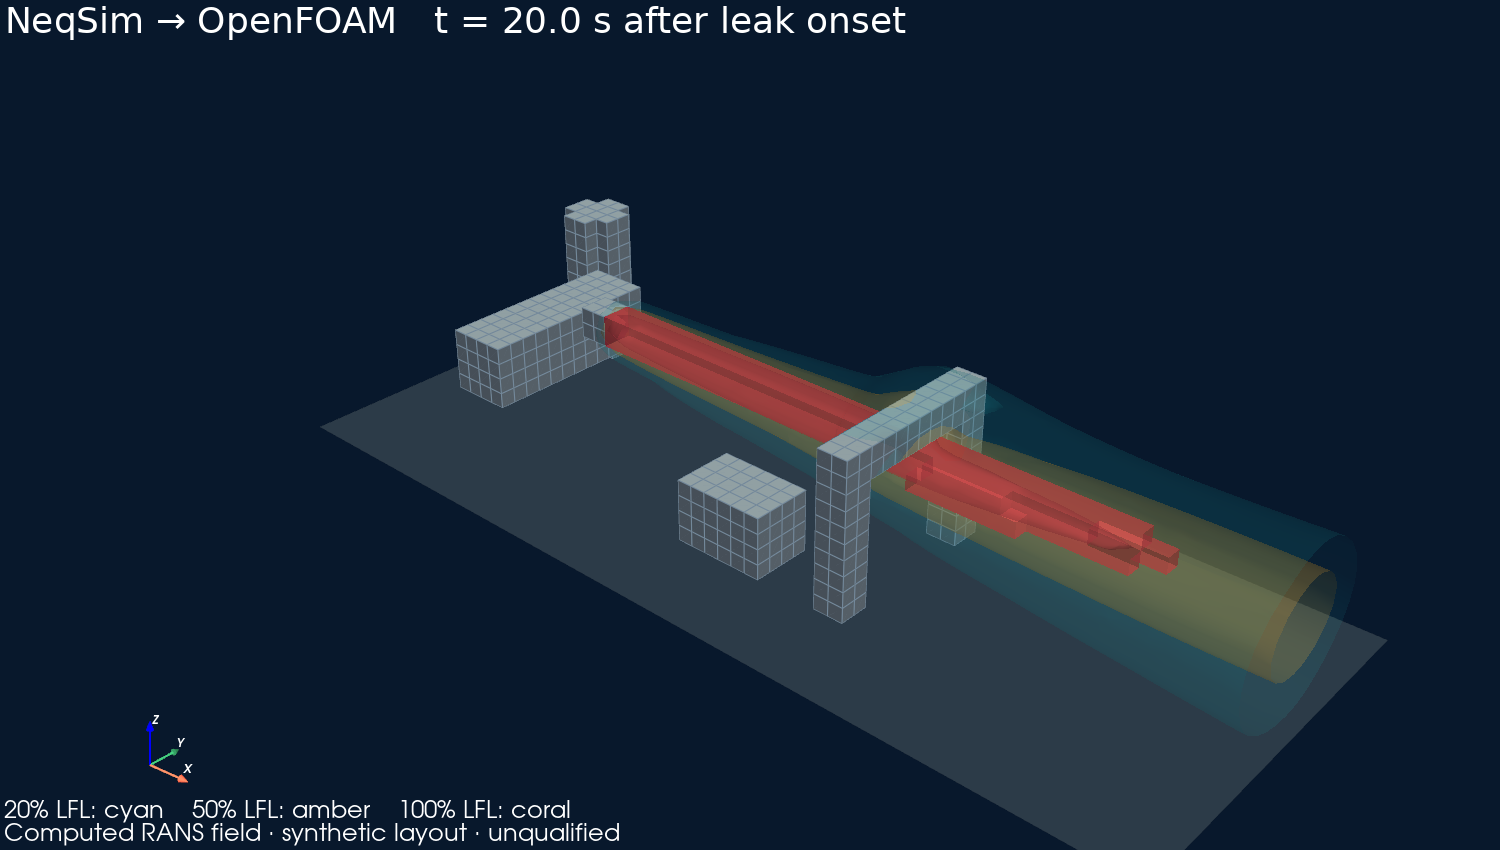

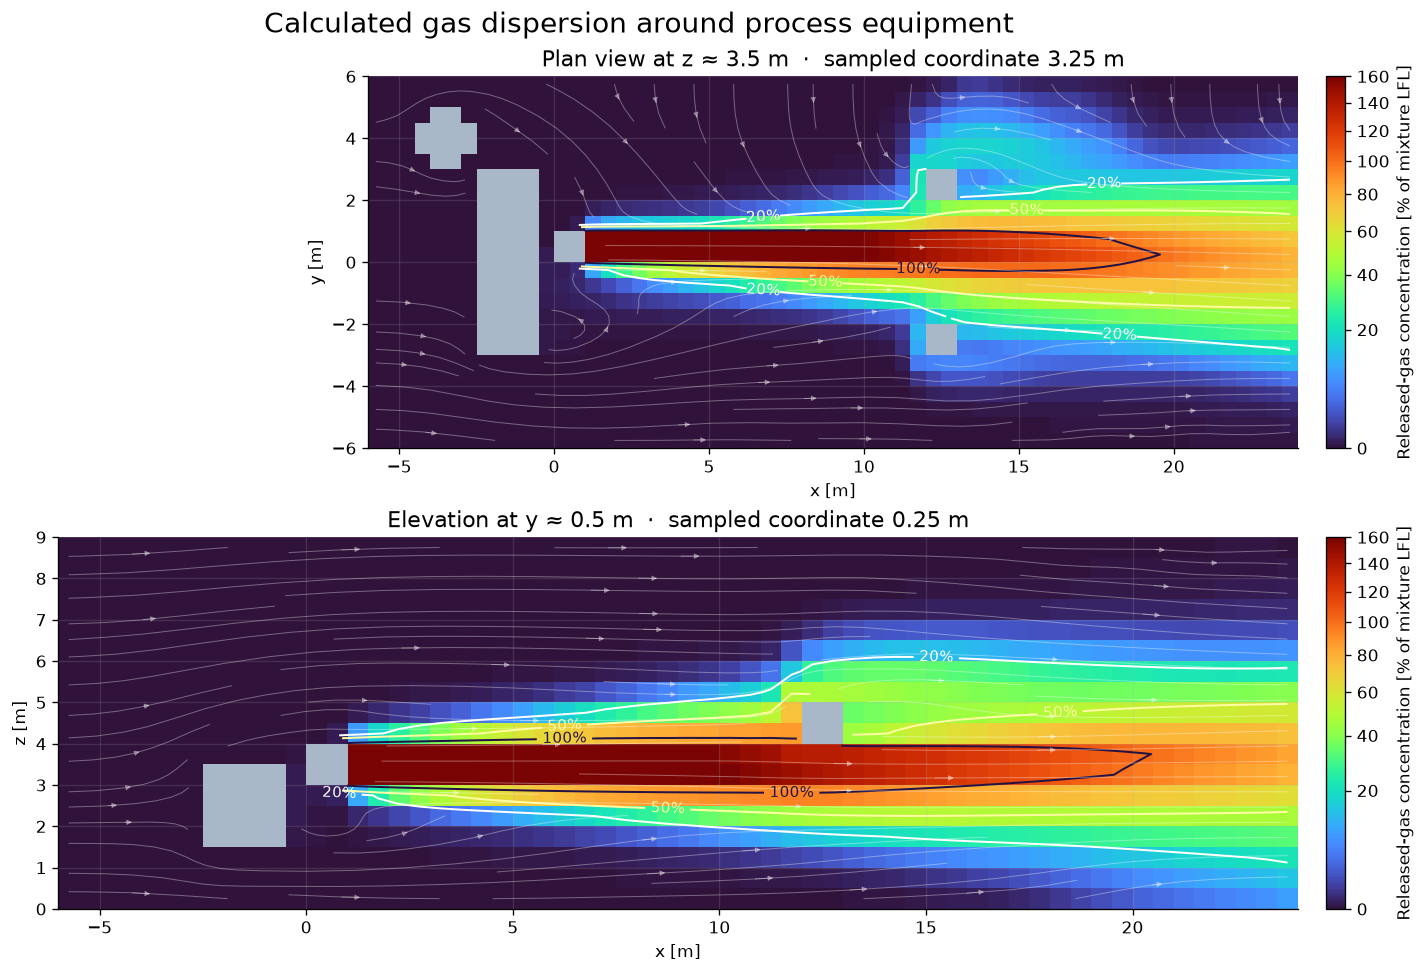

In [17]:
render_3d(case_root / "base", figures_dir / "gas-cloud-3d.png", gas_mw, mixture_lfl)
display(Image(filename=str(figures_dir / "gas-cloud-3d.png")))
plot_slices(case_root / "base", figures_dir / "gas-concentration-slices.png", gas_mw, mixture_lfl)
plt.show()

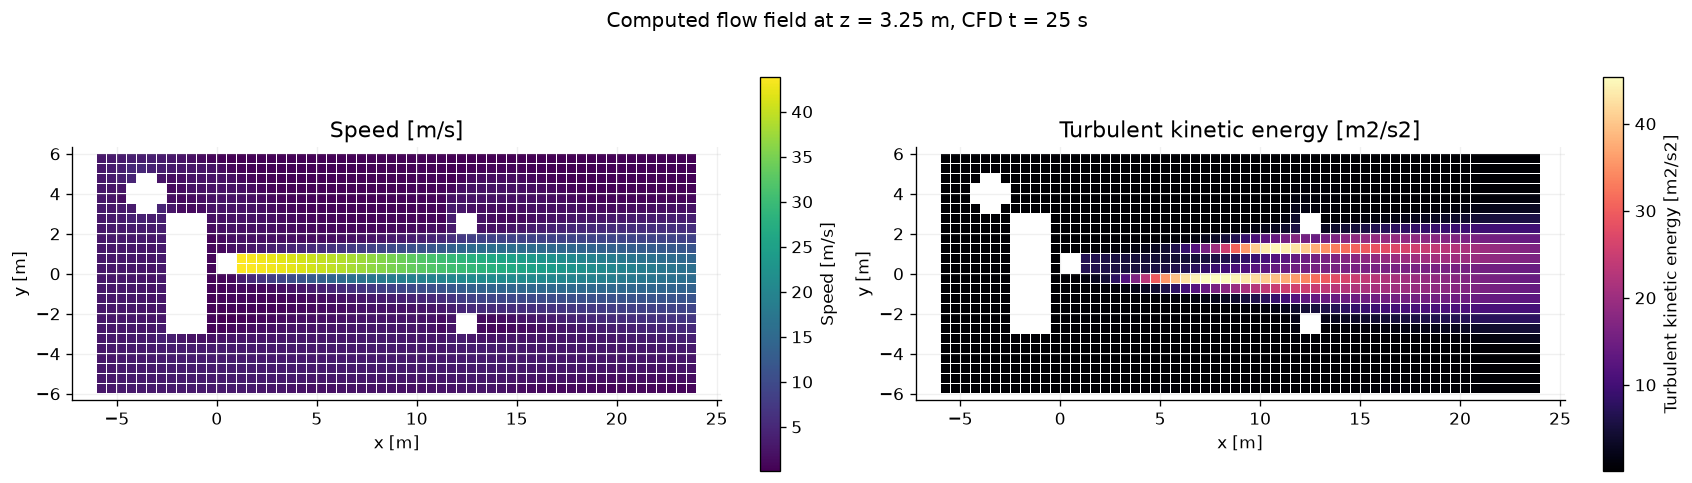

In [18]:
# Velocity and turbulence at the same resolved elevation as the plume.
grid, boundary = load_grid(case_root / "base", 25.0, gas_mw, mixture_lfl)
xyz = grid.cell_centers().points
plane_z = np.unique(xyz[:, 2])[np.argmin(abs(np.unique(xyz[:, 2]) - 3.5))]
selected = np.isclose(xyz[:, 2], plane_z)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), constrained_layout=True)
for ax, values, label, cmap in [
    (axes[0], grid.cell_data["speed_ms"], "Speed [m/s]", "viridis"),
    (axes[1], grid.cell_data["k"], "Turbulent kinetic energy [m2/s2]", "magma"),
]:
    scatter = ax.scatter(
        xyz[selected, 0],
        xyz[selected, 1],
        c=values[selected],
        marker="s",
        s=30,
        cmap=cmap,
        linewidths=0,
    )
    ax.set(xlabel="x [m]", ylabel="y [m]", title=label, aspect="equal")
    fig.colorbar(scatter, ax=ax, label=label, shrink=0.85)
fig.suptitle(f"Computed flow field at z = {plane_z:.2f} m, CFD t = 25 s")
fig.savefig(figures_dir / "velocity-turbulence.png", dpi=160, bbox_inches="tight")
plt.show()

### Movie · the computed cloud through time

The next cell renders **41 actual OpenFOAM snapshots**, spaced 0.5 s apart, from release
onset to 20 s after onset. The camera, geometry and concentration thresholds remain fixed.
The overlay reports the NeqSim release rate, supply isolation state and calculated flammable
volume. Color thresholds match the static figure above; no plume is invented between frames.

The MP4 uses H.264 for browser/Colab playback. Four saved snapshots play per second, so the
simulated event plays at twice real time, with a one-second opening hold and two-second final
hold. The 24 fps encoding repeats frames; it does not add CFD time resolution. The static
3D figure above is the saved fallback for viewers that block embedded video. The movie is
also included in the case archive and can be downloaded after running this cell.


In [19]:
from IPython.display import FileLink, Video

movie_frame_dir = Path("separator_movie_frames")
movie_frame_dir.mkdir(exist_ok=True)
movie_times = np.arange(5.0, 25.01, 0.5)
movie_started = time.monotonic()
for index, cfd_time in enumerate(movie_times):
    release_time = max(0.0, cfd_time - 5.05)
    rate = float(np.interp(release_time, history.time_s, history.rate_kg_s))
    if cfd_time <= 5.0:
        rate = 0.0
        supply_state = "Opening about to release"
    elif release_time < 5.0:
        supply_state = "Supply maintained before isolation"
    else:
        supply_state = "Supply isolated; trapped gas continues to escape"
    table = case_tables["base"]
    row = table.iloc[np.argmin(abs(table.time_s.to_numpy() - cfd_time))]
    annotation = (
        f"Release {rate:.2f} kg/s | Flammable volume {row.flammable_volume_m3:.1f} m3\n"
        f"{supply_state}\nWind 3 m/s toward +x | 2x playback; 0.5 s CFD snapshots"
    )
    render_3d(
        case_root / "base",
        movie_frame_dir / f"frame-{index:03d}.png",
        gas_mw,
        mixture_lfl,
        time=float(cfd_time),
        annotation=annotation,
    )

movie_path = figures_dir / "separator_release_cfd.mp4"
encoded = subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-framerate",
        "4",
        "-i",
        str(movie_frame_dir / "frame-%03d.png"),
        "-frames:v",
        "318",
        "-vf",
        "tpad=start_mode=clone:start_duration=1:stop_mode=clone:stop_duration=2,fps=24",
        "-c:v",
        "libx264",
        "-threads",
        "2",
        "-crf",
        "18",
        "-pix_fmt",
        "yuv420p",
        "-movflags",
        "+faststart",
        str(movie_path),
    ],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)
if encoded.returncode:
    raise RuntimeError(encoded.stderr)
movie_probe = json.loads(
    subprocess.check_output(
        ["ffprobe", "-v", "error", "-show_streams", "-show_format", "-of", "json", str(movie_path)],
        text=True,
    )
)
movie_metadata = {
    "file": str(movie_path.relative_to(results_dir)),
    "source": "Actual base-case OpenFOAM saved fields; fixed camera and LFL thresholds",
    "source_snapshots": len(movie_times),
    "simulation_interval_s": [5.0, 25.0],
    "snapshot_spacing_s": 0.5,
    "video_duration_s": float(movie_probe["format"]["duration"]),
    "video_fps": movie_probe["streams"][0]["avg_frame_rate"],
    "codec": movie_probe["streams"][0]["codec_name"],
    "bytes": movie_path.stat().st_size,
    "render_wall_seconds": time.monotonic() - movie_started,
}
assert movie_metadata["source_snapshots"] == 41
assert movie_metadata["codec"] == "h264"
assert 13.0 <= movie_metadata["video_duration_s"] <= 13.5
display(pd.DataFrame(movie_metadata.items(), columns=["Movie evidence", "Value"]))
display(
    Video(
        filename=str(movie_path),
        embed=True,
        width=1000,
        html_attributes="controls loop muted playsinline",
    )
)
display(FileLink(str(movie_path)))

,Movie evidence,Value
0,file,figures/separator_release_cfd.mp4
1,source,Actual base-case OpenFOAM saved fields; fixed camera and LFL thresholds
2,source_snapshots,41
3,simulation_interval_s,"[5.0, 25.0]"
4,snapshot_spacing_s,0.5
5,video_duration_s,13.25
6,video_fps,24/1
7,codec,h264
8,bytes,363624
9,render_wall_seconds,30.56127


/workspace/scratch/d59c271f86ae/movie-run/separator_release_results/figures/separator_release_cfd.mp4

## 9 · Virtual detectors and flammable cloud development

D1–D3 sample the downstream jet corridor; D4 samples an off-axis low-level location. The exact cell
centers are printed, because finite mesh spacing affects a point sample. The illustrative 20% and
60% LFL levels are not asserted as a site alarm standard. Detector response time, calibration,
weather distributions, voting, availability and coverage are not modelled.

,x [m],y [m],z [m]
D1,3.75,0.25,3.75
D2,7.75,0.25,3.75
D3,16.25,0.25,3.25
D4,7.75,2.75,1.25


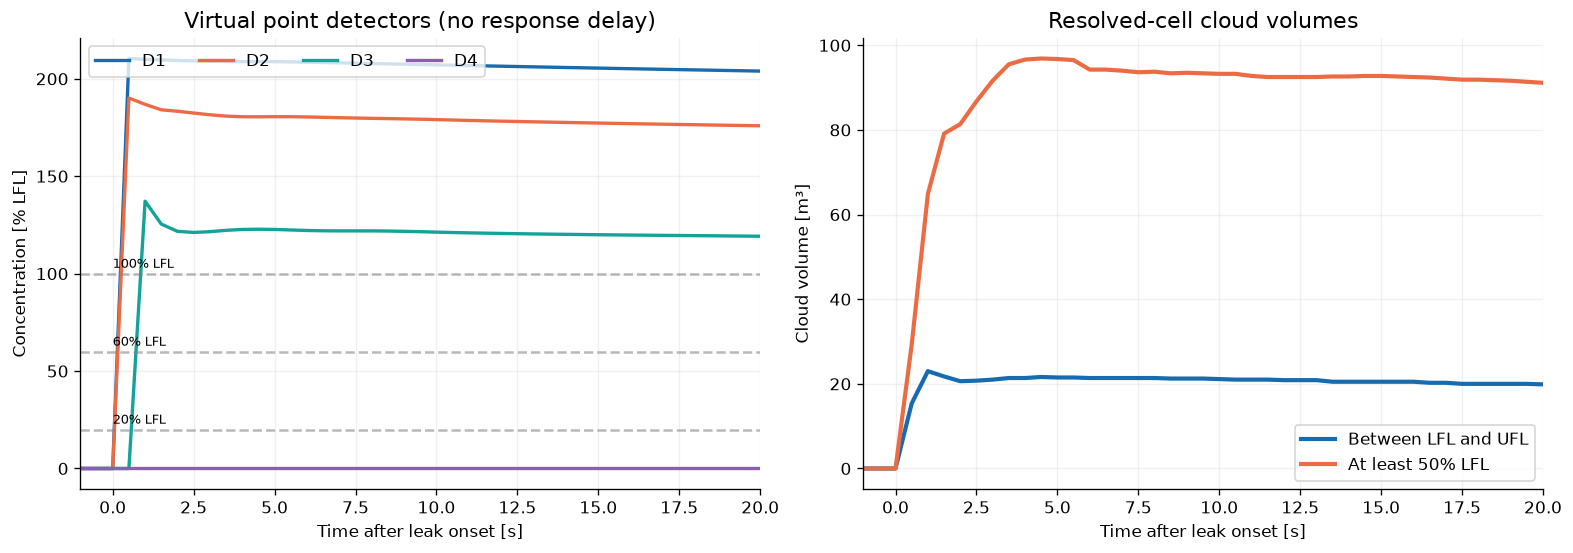

,Detector,Peak [% LFL],First sampled 20% LFL [s after onset]
0,D1,210.414602,0.5
1,D2,190.122547,0.5
2,D3,137.178399,1.0
3,D4,0.000056,NaN


In [20]:
base_table = case_tables["base"]
display(
    pd.DataFrame(
        case_diagnostics["base"]["probe_cell_centres_m"],
        columns=["x [m]", "y [m]", "z [m]"],
        index=["D1", "D2", "D3", "D4"],
    )
)
detector_figure(base_table, figures_dir / "detectors-cloud.png")
plt.show()
detector_results = []
for detector in range(1, 5):
    concentration = base_table[f"D{detector}_percent_LFL"]
    reached = base_table.time_s[concentration >= 20]
    detector_results.append(
        {
            "Detector": f"D{detector}",
            "Peak [% LFL]": concentration.max(),
            "First sampled 20% LFL [s after onset]": None if reached.empty else reached.iloc[0] - 5,
        }
    )
display(pd.DataFrame(detector_results))

## 10 · Conservation and numerical sensitivity

The species audit reconstructs gas mass from the CFD EOS and integrates **advective plus diffusive
boundary fluxes**, including the release surface. The residual includes 0.5 s output quadrature
error, especially at the short startup ramp, and reconstruction differences from the solver's
face discretization. It is not the solver's exact algebraic residual. Total-flow continuity from
the solver log is reported separately.

The 1 m and 0.5 m meshes change both cell size and stair-stepped geometry. The timestep comparison
uses the 1 m grid. These are **sensitivity checks**, not a three-grid convergence study or proof of
grid independence. Differences should inform further refinement rather than be tuned away.

The extended-domain case uses the same 1 m grid with the outlet moved from x = 24 to 60 m. A cloud intersecting an open boundary has a truncated volume; an LFL cloud reaching the outlet gives only a lower bound on downstream extent. These flags are reported explicitly. The adaptive Courant controller responds after a step: the 0.05 s source ramp can briefly exceed its target. Actual maximum Courant numbers are retained, and the smaller-target run tests this sensitivity; the result is not asserted time-converged.

Solver Courant/continuity summaries apply only to the log interval reported in `solver_log_start_time_s`; reconstructed species budgets use the complete saved-field history. A verification restart is explicitly identified in run evidence when applicable.

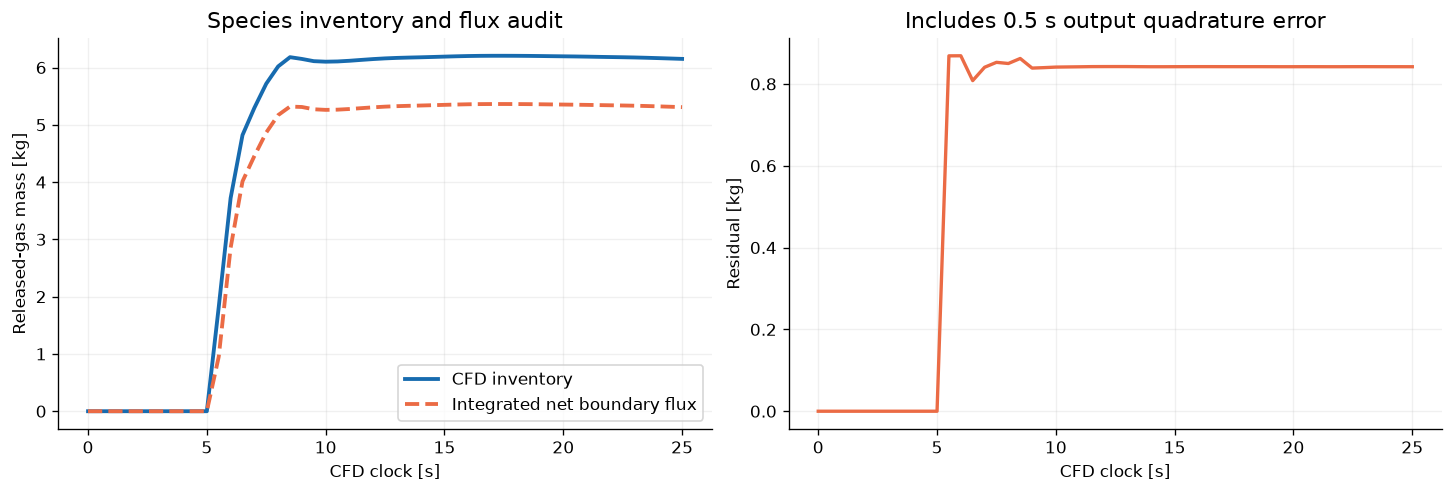

Case,base,coarse,time_step,fast_wind,long_domain
Cells,25392,3173,3173,3173,7061
Gas in domain [kg],6.151,5.883,5.973,7.104,26.768
Flammable volume [m3],19.875,23.0,23.0,20.0,26.0
50% LFL volume [m3],91.125,53.0,53.0,86.0,137.0
LFL downstream extent [m],19.5,23.0,23.0,20.0,26.0
50% LFL downstream extent [m],23.0,23.0,23.0,23.0,39.0
LFL reaches outlet,False,True,True,False,False
50% LFL touches open boundary,True,True,True,True,False
Fuel-budget error [%],1.143,1.023,0.944,1.382,1.173


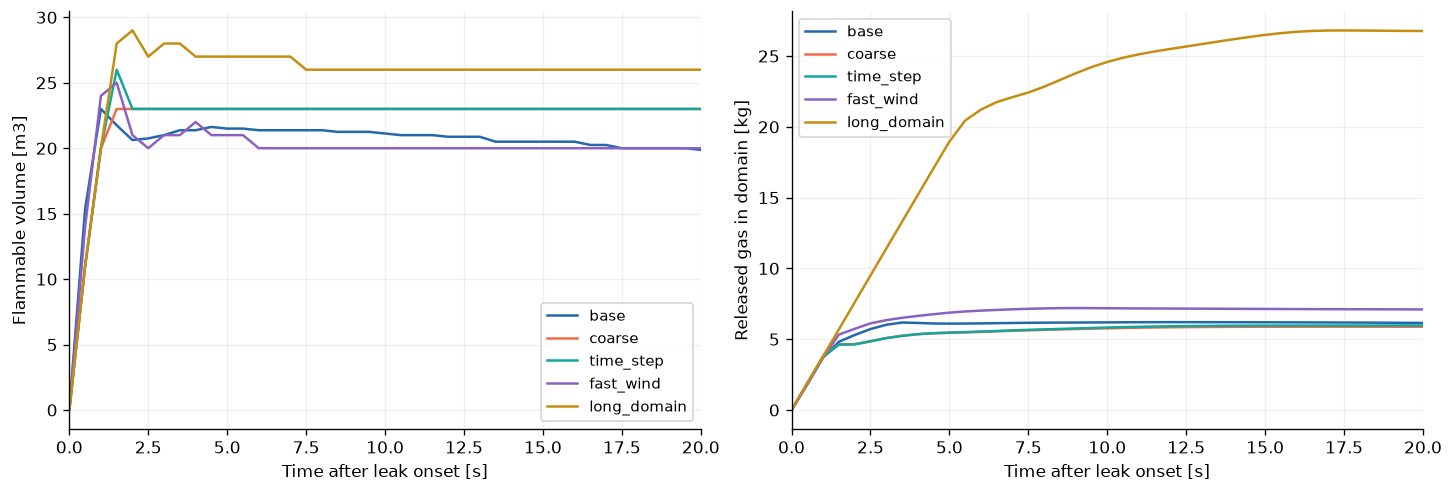

In [21]:
budget_figure(base_table, figures_dir / "fuel-budget.png")
plt.show()
comparison_rows = []
for name, table in case_tables.items():
    final = table.iloc[-1]
    comparison_rows.append(
        {
            "Case": name,
            "Cells": case_diagnostics[name]["cells"],
            "Gas in domain [kg]": final.cloud_fuel_kg,
            "Flammable volume [m3]": final.flammable_volume_m3,
            "50% LFL volume [m3]": final.half_lfl_volume_m3,
            "LFL downstream extent [m]": final.lfl_extent_m,
            "50% LFL downstream extent [m]": final.half_lfl_extent_m,
            "LFL reaches outlet": bool(final.outlet_max_percent_LFL >= 100),
            "50% LFL touches open boundary": bool(final.open_boundary_max_percent_LFL >= 50),
            "Fuel-budget error [%]": case_diagnostics[name]["fuel_budget_error_percent"],
        }
    )
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(3).set_index("Case").T)
comparison.to_csv(results_dir / "case-comparison.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
case_colors = ["#2368ac", "#f56a45", "#12a69e", "#8a62c1", "#c58d12"]
for (name, table), color in zip(case_tables.items(), case_colors):
    axes[0].plot(table.time_s - 5, table.flammable_volume_m3, label=name, color=color)
    axes[1].plot(table.time_s - 5, table.cloud_fuel_kg, label=name, color=color)
axes[0].set(xlabel="Time after leak onset [s]", ylabel="Flammable volume [m3]", xlim=(0, 20))
axes[1].set(xlabel="Time after leak onset [s]", ylabel="Released gas in domain [kg]", xlim=(0, 20))
for ax in axes:
    ax.legend(fontsize=9)
fig.savefig(figures_dir / "case-sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

## 11 · Scenario register and the next professional-study steps

The executed cases cover one opening, one source orientation, one isolation delay, neutral uniform
wind and two speeds. A professional scenario register should add release sizes (for example 5, 10,
25 and 50 mm), gas/liquid/full-bore classes, source directions, operating conditions, isolation/ESD
success and failure, blowdown routing, stable low-wind cases and wind sectors. Full-bore pipeline
rupture requires a separate transient pipe model; it is not a larger orifice selected by diameter.

Frequencies, ignition probabilities, fatalities, explosion overpressure and fire radiation are
**not calculated**. The native generator's generic consequence-branch metadata must not be mistaken
for an agreed QRA probability basis. This notebook does not compute individual or societal risk.

Before a design issue: qualify source physics, verify isolation volumes and actual CAD, model the
atmospheric boundary layer, examine source area/stand-off and turbulence/Schmidt sensitivity,
demonstrate domain/startup independence, complete mesh/time convergence, compare with relevant
published or experimental dispersion benchmarks, and obtain independent safety-domain review.

In [22]:
final = base_table.iloc[-1]
display(
    Markdown(
        f"**Calculated base-case snapshot, {final.time_s-5:.0f} s after onset:** "
        f"{final.flammable_volume_m3:.1f} m³ between the screening LFL and UFL; "
        f"{final.half_lfl_volume_m3:.1f} m³ at or above 50% LFL; "
        f"{final.cloud_fuel_kg:.2f} kg of released gas remains in the CFD domain. "
        f"The LFL downstream extent from the virtual source plane is {final.lfl_extent_m:.1f} m within this domain. "
        "These values inherit the source, mesh and weather limitations above."
    )
)
if final.outlet_max_percent_LFL >= 100:
    display(
        Markdown(
            "**Domain truncation:** LFL gas reaches the outlet; the downstream distance is a lower bound."
        )
    )
if final.open_boundary_max_percent_LFL >= 50:
    display(
        Markdown(
            "**Domain truncation:** the 50% LFL cloud reaches an open boundary; its complete volume is not captured."
        )
    )

**Calculated base-case snapshot, 20 s after onset:** 19.9 m³ between the screening LFL and UFL; 91.1 m³ at or above 50% LFL; 6.15 kg of released gas remains in the CFD domain. The LFL downstream extent from the virtual source plane is 19.5 m within this domain. These values inherit the source, mesh and weather limitations above.

**Domain truncation:** the 50% LFL cloud reaches an open boundary; its complete volume is not captured.

## 12 · Reusable files and provenance

The archive contains the process/source CSV files, native screening export, all case dictionaries
and initial fields, final CFD fields, transient diagnostic CSVs, figures, the MP4 movie and run evidence.
The full saved time directories remain in `separator_release_results/OpenFOAM` during the run.
Open a case's `case.foam` file in ParaView to inspect the final solution; run it from its initial
fields with `rhoReactingBuoyantFoam -noFunctionObjects -case CASE` to reproduce the history.

Source coordinates use a local Cartesian frame in metres; wind is a velocity toward +x, not a
meteorological wind-from bearing. Interchange should carry coordinate reference, orientation,
simulation clock, units, model identity and qualification status along with the time series.

### Run an exported case outside Colab

Extract the archive, install the same OpenCFD OpenFOAM v1912 build and open a shell in the
extracted directory. These are the same commands executed by `run_case`:

```bash
export WM_PROJECT_DIR=/usr/share/openfoam
export WM_PROJECT_VERSION=v1912
export FOAM_ETC=/usr/share/openfoam/etc
checkMesh -case OpenFOAM/base > OpenFOAM/base/log.checkMesh 2>&1
rhoReactingBuoyantFoam -noFunctionObjects -case OpenFOAM/base \
  > OpenFOAM/base/log.rhoReactingBuoyantFoam 2>&1
```

The supplied `controlDict` starts from time 0 and writes the complete transient history.
Run into a fresh extracted folder if you want to retain the previous results and logs.
For ParaView, open `OpenFOAM/base/case.foam`, apply the reader, select a saved time and color
the volume or slices by `fuel`, `U` or `T`. The notebook's LFL figures convert `fuel` mass
fraction to released-gas mole fraction before dividing by the mixture LFL.

The default archive includes all input files and final fields for a compact download. Set
`INCLUDE_ALL_CFD_TIMES = True` in the next cell to include every saved transient field as well.
That increases archive size; it does not change the calculation or its inline diagnostics.


In [23]:
import zipfile

INCLUDE_ALL_CFD_TIMES = False

run_manifest = {
    "neqsim": provenance,
    "dependencies": versions,
    "openfoam": "OpenCFD v1912 / patch 200626",
    "qualification": "UNQUALIFIED_DEMONSTRATION",
    "process_checks": process_checks,
    "inventory_checks": inventory_checks,
    "source_model": "Native IdealGasReleaseModel rate/throat + SRK ReleaseInventory; explicit approximation",
    "source_model_audit": audit,
    "native_source_schema": first_frame["schemaVersion"],
    "native_source_frames": len(saved_frames),
    "native_frame_file": native_frame_path.name,
    "cfd": case_diagnostics,
    "case_settings": case_settings,
    "execution": execution_evidence,
    "movie": movie_metadata,
    "issues": [
        "https://github.com/equinor/neqsim/issues/3860",
        "https://github.com/equinor/neqsim/issues/3905",
    ],
}
(results_dir / "run-manifest.json").write_text(json.dumps(run_manifest, indent=2))
archive_path = Path("separator_release_openfoam_cases.zip")
with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
    for file_path in results_dir.rglob("*"):
        if not file_path.is_file():
            continue
        relative = file_path.relative_to(results_dir)
        parts = relative.parts
        if len(parts) > 2 and parts[0] == "OpenFOAM":
            folder = parts[2]
            if (
                not INCLUDE_ALL_CFD_TIMES
                and folder.replace(".", "", 1).isdigit()
                and folder not in ["0", "25"]
            ):
                continue
        archive.write(file_path, relative)
print(
    "Case archive:", archive_path.resolve(), "| MiB:", round(archive_path.stat().st_size / 2**20, 2)
)
print("All process, source, mesh-completion, species-bounds and fuel-budget gates passed.")
from IPython.display import FileLink

display(FileLink(str(archive_path)))


def download_cases(_):
    from google.colab import files

    files.download(str(archive_path))


if "google.colab" in sys.modules:
    import ipywidgets as widgets

    download_button = widgets.Button(description="Download CFD cases", button_style="success")
    download_button.on_click(download_cases)
    display(download_button)

Case archive: /workspace/scratch/d59c271f86ae/movie-run/separator_release_openfoam_cases.zip | MiB: 11.29
All process, source, mesh-completion, species-bounds and fuel-budget gates passed.


/workspace/scratch/d59c271f86ae/movie-run/separator_release_openfoam_cases.zip

### Primary references and qualification boundary

- [NeqSim automatic scenarios and CFD handoff](https://equinor.github.io/neqsim/process/safety/release-dispersion-scenarios.html)
- [Native source-term exchange contract](https://github.com/equinor/neqsim/blob/3e35bb26591a0d838abed7fdb2d75a35ff2b136c/docs/process/safety/source-term-contract.md)
- [Release-flow model definitions and validity](https://github.com/equinor/neqsim/blob/3e35bb26591a0d838abed7fdb2d75a35ff2b136c/docs/process/safety/release-flow-models.md)
- [Conservative gas inventory](https://github.com/equinor/neqsim/blob/3e35bb26591a0d838abed7fdb2d75a35ff2b136c/docs/process/safety/coupled-release-inventory.md)
- [OpenFOAM solver families](https://www.openfoam.com/documentation/user-guide/a-reference/a.1-standard-solvers)
- [OpenFOAM thermophysical models](https://www.openfoam.com/documentation/user-guide/5-models-and-physical-properties/5.2-thermophysical-models)
- [NIOSH propane](https://www.cdc.gov/niosh/npg/npgd0524.html), [OSHA butane](https://www.osha.gov/chemicaldata/49), [NIOSH pentane](https://www.cdc.gov/niosh/npg/npgd0486.html), [NIOSH heptane](https://www.cdc.gov/niosh/npg/npgd0312.html)
- [Source-term qualification roadmap #3860](https://github.com/equinor/neqsim/issues/3860)
- [Legacy blowdown defect #3905](https://github.com/equinor/neqsim/issues/3905)

**Evidence achieved:** source-provenance verification, process/component/energy closure, conservative
inventory checks, timestep sensitivity, source-transfer closure, a mixed-inlet equilibrium phase
check, OpenFOAM mesh checks, completed CFD solves, bounded species, reconstructed fuel budgets,
mesh/time/wind sensitivity and rendered-output inspection. **Not achieved:** independent
experimental CFD validation, nozzle/entrainment qualification, grid independence or an asset safety case.

**Documentation impact:** new executable notebook, README/catalog entry and validation ledger;
no NeqSim Java model or native schema is modified. The notebook's source/case assumptions are
documented here and in the exported manifest.